In [1]:
#!/usr/bin/env python3
"""
Interactive 3D Tumor Visualization with DICOM Processing
=========================================================

Combined script for NSCLC-Radiomics dataset:
- Load CT DICOM series and Segmentation
- Extract tumor segment automatically
- Create interactive 3D visualizations (Plotly or Matplotlib)

Usage in Jupyter:
    %run visualize_tumor_3d_combined.py
    
    # List patients
    list_patients()
    
    # Visualize single patient
    show_patient_3d("LUNG1-001")
    
    # Compare 2 patients
    show_two_patients_3d(["LUNG1-001", "LUNG1-002"])
    
    # Random comparison
    show_two_patients_3d()
"""

import os
import numpy as np
import random
import pydicom
import warnings
from pathlib import Path
from scipy.ndimage import zoom

warnings.filterwarnings('ignore')

# Try to import plotly for interactive 3D
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("⚠️  Plotly not installed. Install with: pip install plotly")
    print("   Falling back to matplotlib...")

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# CONFIG
# ============================================================

DATA_DIR = "nsclc"
OUTPUT_DIR = "data_3d_ae"


# ============================================================
# DICOM PROCESSING FUNCTIONS
# ============================================================

def slice_order_key(ds):
    """Determine CT slice order."""
    inst = getattr(ds, "InstanceNumber", None)
    if inst is not None:
        return float(inst)
    
    ipp = getattr(ds, "ImagePositionPatient", None)
    if ipp is not None and len(ipp) > 2:
        return float(ipp[2])
    
    return 0.0


def load_ct_volume(ct_dir):
    """Load CT DICOM series as 3D volume."""
    ct_dir = Path(ct_dir)
    dcm_files = sorted(ct_dir.glob("*.dcm"))
    
    if not dcm_files:
        raise ValueError(f"No DICOM files found in {ct_dir}")
    
    ct_dcms = []
    for dcm_path in dcm_files:
        try:
            ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=False)
            if hasattr(ds, 'Modality') and ds.Modality == 'CT':
                ct_dcms.append(ds)
        except Exception:
            pass
    
    if not ct_dcms:
        raise ValueError(f"No valid CT DICOM files in {ct_dir}")
    
    ct_dcms.sort(key=slice_order_key)
    pixel_spacing = ct_dcms[0].PixelSpacing
    
    if len(ct_dcms) > 1:
        slice_thickness = getattr(ct_dcms[0], 'SliceThickness', None)
        if slice_thickness is None:
            pos1 = ct_dcms[0].ImagePositionPatient[2]
            pos2 = ct_dcms[1].ImagePositionPatient[2]
            slice_thickness = abs(pos2 - pos1)
    else:
        slice_thickness = 1.0
    
    spacing = (float(pixel_spacing[0]), float(pixel_spacing[1]), float(slice_thickness))
    ct_vol = np.stack([ds.pixel_array for ds in ct_dcms], axis=0)
    
    if hasattr(ct_dcms[0], 'RescaleSlope') and hasattr(ct_dcms[0], 'RescaleIntercept'):
        slope = ct_dcms[0].RescaleSlope
        intercept = ct_dcms[0].RescaleIntercept
        ct_vol = ct_vol * slope + intercept
    
    return ct_vol, ct_dcms, spacing


def get_segment_labels(seg_ds):
    """Extract segment labels from DICOM Segmentation dataset."""
    segment_labels = {}
    
    if hasattr(seg_ds, 'SegmentSequence'):
        for segment in seg_ds.SegmentSequence:
            seg_num = segment.SegmentNumber
            label = getattr(segment, 'SegmentLabel', f'Segment_{seg_num}')
            segment_labels[seg_num] = label
    
    return segment_labels


def find_tumor_segment_number(seg_ds):
    """
    Find segment number for tumor.
    
    Strategy:
    1. Look for segments with tumor-related keywords
    2. If only one segment exists, use that
    3. Fallback to segment #2 (NSCLC-Radiomics: tumor is usually segment 2)
    """
    if not hasattr(seg_ds, 'SegmentSequence'):
        raise ValueError("No SegmentSequence found in segmentation")
    
    segments = seg_ds.SegmentSequence
    segment_labels = get_segment_labels(seg_ds)
    
    # If only one segment, use it
    if len(segments) == 1:
        return segments[0].SegmentNumber
    
    # Look for tumor-related keywords
    tumor_keywords = ['tumor', 'tumour', 'neoplasm', 'primary', 'gtv', 'cancer', 'mass', 'lesion']
    
    for segment in segments:
        seg_num = segment.SegmentNumber
        label = getattr(segment, 'SegmentLabel', '').lower()
        description = getattr(segment, 'SegmentDescription', '').lower()
        
        for keyword in tumor_keywords:
            if keyword in label or keyword in description:
                return seg_num
        
        if hasattr(segment, 'SegmentedPropertyTypeCodeSequence'):
            type_seq = segment.SegmentedPropertyTypeCodeSequence[0]
            type_meaning = getattr(type_seq, 'CodeMeaning', '').lower()
            for keyword in tumor_keywords:
                if keyword in type_meaning:
                    return seg_num
    
    # Fallback: In NSCLC-Radiomics, tumor is usually segment #2
    if 2 in segment_labels:
        return 2
    
    # Last resort: use first segment
    return segments[0].SegmentNumber


def load_segmentation(seg_file, ct_dcms, debug=False):
    """
    Load DICOM SEG and create 3D mask for TUMOR ONLY.
    
    Returns:
        mask : np.array (slices, rows, cols) - Binary mask with 1 = tumor, 0 = background
    """
    seg_file = Path(seg_file)
    seg = pydicom.dcmread(str(seg_file))
    
    if seg.Modality != "SEG":
        raise ValueError(f"Not a DICOM SEG file. Modality: {seg.Modality}")
    
    # Get segment labels and find tumor
    segment_labels = get_segment_labels(seg)
    tumor_seg_num = find_tumor_segment_number(seg)
    
    if debug:
        print(f"    Segments found: {segment_labels}")
        print(f"    Selected tumor segment: #{tumor_seg_num} - {segment_labels.get(tumor_seg_num, 'Unknown')}")
    
    # Read frames
    frames = seg.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]
    
    # Initialize mask
    num_slices = len(ct_dcms)
    rows = int(ct_dcms[0].Rows)
    cols = int(ct_dcms[0].Columns)
    mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)
    
    # Create SOP UID to index mapping
    sop_to_index = {ds.SOPInstanceUID: i for i, ds in enumerate(ct_dcms)}
    
    # Map frames to slices
    tumor_frames_mapped = 0
    
    if not hasattr(seg, 'PerFrameFunctionalGroupsSequence'):
        # Fallback: direct frame mapping
        if debug:
            print(f"    Warning: No PerFrameFunctionalGroupsSequence, using direct frame mapping")
        for frame_idx in range(min(len(frames), num_slices)):
            if frames[frame_idx].max() > 0:
                mask[frame_idx] = (frames[frame_idx] > 0).astype(np.uint8)
                tumor_frames_mapped += 1
    else:
        pffg = seg.PerFrameFunctionalGroupsSequence
        
        for frame_idx, frame_info in enumerate(pffg):
            if frame_idx >= len(frames):
                break
            
            # Get segment number for this frame
            frame_seg_num = None
            if hasattr(frame_info, 'SegmentIdentificationSequence'):
                if len(frame_info.SegmentIdentificationSequence) > 0:
                    frame_seg_num = frame_info.SegmentIdentificationSequence[0].ReferencedSegmentNumber
            
            # Process if matches tumor segment (or if segment number not specified)
            process_frame = (frame_seg_num is None or frame_seg_num == tumor_seg_num)
            
            if process_frame:
                ref_sop = None
                slice_idx = None
                
                # Method 1: DerivationImageSequence
                if hasattr(frame_info, 'DerivationImageSequence'):
                    if len(frame_info.DerivationImageSequence) > 0:
                        deriv = frame_info.DerivationImageSequence[0]
                        if hasattr(deriv, 'SourceImageSequence'):
                            if len(deriv.SourceImageSequence) > 0:
                                ref_image = deriv.SourceImageSequence[0]
                                ref_sop = ref_image.ReferencedSOPInstanceUID
                
                # Method 2: ReferencedImageSequence
                if ref_sop is None and hasattr(frame_info, 'ReferencedImageSequence'):
                    if len(frame_info.ReferencedImageSequence) > 0:
                        ref_image = frame_info.ReferencedImageSequence[0]
                        if hasattr(ref_image, 'ReferencedSOPInstanceUID'):
                            ref_sop = ref_image.ReferencedSOPInstanceUID
                
                # Method 3: PlanePositionSequence
                if ref_sop is None and hasattr(frame_info, 'PlanePositionSequence'):
                    if len(frame_info.PlanePositionSequence) > 0:
                        plane_pos = frame_info.PlanePositionSequence[0]
                        if hasattr(plane_pos, 'ImagePositionPatient'):
                            frame_ipp = plane_pos.ImagePositionPatient
                            for i, ct_ds in enumerate(ct_dcms):
                                if hasattr(ct_ds, 'ImagePositionPatient'):
                                    ct_ipp = ct_ds.ImagePositionPatient
                                    if all(abs(float(frame_ipp[j]) - float(ct_ipp[j])) < 0.1 for j in range(3)):
                                        slice_idx = i
                                        break
                
                # Map using SOP UID
                if ref_sop and ref_sop in sop_to_index:
                    slice_idx = sop_to_index[ref_sop]
                
                # Method 4: Direct frame index mapping (fallback)
                if slice_idx is None and len(frames) == num_slices:
                    slice_idx = frame_idx
                
                # Apply mask
                if slice_idx is not None and slice_idx < num_slices:
                    if frames[frame_idx].max() > 0:
                        mask[slice_idx] = np.maximum(mask[slice_idx], (frames[frame_idx] > 0).astype(np.uint8))
                        tumor_frames_mapped += 1
    
    if debug:
        print(f"    Mapped {tumor_frames_mapped} tumor frames to CT slices")
        print(f"    Total tumor voxels: {mask.sum():,}")
    
    if mask.sum() == 0:
        raise ValueError(f"No tumor voxels found for segment {tumor_seg_num}")
    
    return mask


def find_patient_data(data_dir):
    """Find all patient folders with CT and SEG data."""
    data_dir = Path(data_dir)
    
    # Navigate to NSCLC-Radiomics folder
    if data_dir.name != "NSCLC-Radiomics":
        manifest_folders = list(data_dir.glob("manifest-*/NSCLC-Radiomics"))
        
        if manifest_folders:
            data_dir = manifest_folders[0]
        else:
            if (data_dir / "NSCLC-Radiomics").exists():
                data_dir = data_dir / "NSCLC-Radiomics"
    
    patient_folders = sorted(data_dir.glob("LUNG1-*"))
    
    if len(patient_folders) == 0:
        return []
    
    patient_data = []
    
    for patient_folder in patient_folders:
        patient_id = patient_folder.name
        study_folders = [f for f in patient_folder.iterdir() if f.is_dir()]
        
        if not study_folders:
            continue
        
        study_folder = study_folders[0]
        ct_dir = None
        seg_dir = None
        
        for series_folder in study_folder.iterdir():
            if not series_folder.is_dir():
                continue
            
            series_name = series_folder.name
            
            if series_name.startswith("300."):
                seg_dir = series_folder
            else:
                dcm_count = len(list(series_folder.glob("*.dcm")))
                if dcm_count > 0:
                    if ct_dir is None:
                        ct_dir = series_folder
                    else:
                        current_count = len(list(ct_dir.glob("*.dcm")))
                        if dcm_count > current_count:
                            ct_dir = series_folder
        
        if ct_dir is None or seg_dir is None:
            continue
        
        seg_files = list(seg_dir.glob("*.dcm"))
        if not seg_files:
            continue
        
        seg_file = seg_files[0]
        
        patient_data.append({
            "patient_id": patient_id,
            "patient_dir": patient_folder,
            "ct_dir": ct_dir,
            "seg_file": seg_file
        })
    
    return patient_data


# ============================================================
# VISUALIZATION FUNCTIONS (PLOTLY)
# ============================================================

def visualize_tumor_plotly(ct_vol, mask, patient_id, output_dir="data_3d_ae",
                           max_points=50000, auto_open=True):
    """Create interactive 3D visualization using Plotly."""
    if not HAS_PLOTLY:
        print("❌ Plotly not available. Use matplotlib version instead.")
        return None
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    print(f"\n🎨 Creating interactive 3D visualization (Plotly)...")
    
    # Get tumor coordinates
    tumor_coords = np.where(mask > 0)
    n_voxels = len(tumor_coords[0])
    
    print(f"   Total tumor voxels: {n_voxels:,}")
    
    if n_voxels == 0:
        print("   ⚠️ No tumor voxels to visualize!")
        return None
    
    # Subsample if too large
    if n_voxels > max_points:
        print(f"   Subsampling to {max_points:,} points...")
        indices = np.random.choice(n_voxels, max_points, replace=False)
        z_coords = tumor_coords[0][indices]
        y_coords = tumor_coords[1][indices]
        x_coords = tumor_coords[2][indices]
    else:
        z_coords = tumor_coords[0]
        y_coords = tumor_coords[1]
        x_coords = tumor_coords[2]
    
    # Get CT intensity values at tumor positions
    ct_values = ct_vol[z_coords, y_coords, x_coords]
    print(f"   CT intensity range: {ct_values.min():.0f} to {ct_values.max():.0f} HU")
    
    # Create subplots: 3D scatter + 3 projections
    fig = make_subplots(
        rows=2, cols=2,
        specs=[
            [{'type': 'scatter3d', 'rowspan': 2}, {'type': 'heatmap'}],
            [None, {'type': 'heatmap'}]
        ],
        subplot_titles=(
            '3D Tumor Visualization (Interactive)',
            'XY Projection (Top View)',
            'YZ Projection (Side View)'
        ),
        vertical_spacing=0.12,
        horizontal_spacing=0.1
    )
    
    # 1. 3D Scatter plot
    scatter_3d = go.Scatter3d(
        x=x_coords, y=y_coords, z=z_coords,
        mode='markers',
        marker=dict(
            size=2,
            color=ct_values,
            colorscale='Hot',
            showscale=True,
            colorbar=dict(title="HU", x=0.45, len=0.9),
            opacity=0.6
        ),
        name='Tumor',
        hovertemplate='<b>Position</b><br>X: %{x}<br>Y: %{y}<br>Z: %{z}<br>HU: %{marker.color:.0f}<extra></extra>'
    )
    fig.add_trace(scatter_3d, row=1, col=1)
    
    # 2. XY Projection
    projection_xy = mask.max(axis=0)
    fig.add_trace(
        go.Heatmap(z=projection_xy, colorscale='Reds', showscale=False,
                  hovertemplate='X: %{x}<br>Y: %{y}<extra></extra>'),
        row=1, col=2
    )
    
    # 3. YZ Projection
    projection_yz = mask.max(axis=2)
    fig.add_trace(
        go.Heatmap(z=projection_yz, colorscale='Reds', showscale=False,
                  hovertemplate='Z: %{x}<br>Y: %{y}<extra></extra>'),
        row=2, col=2
    )
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f'{patient_id} - Interactive 3D Tumor Visualization<br>' +
                 f'<sub>Total voxels: {n_voxels:,} | Shape: {mask.shape}</sub>',
            x=0.5, xanchor='center'
        ),
        height=800,
        showlegend=False,
        hovermode='closest'
    )
    
    # Update 3D scene
    fig.update_scenes(
        xaxis_title='X (columns)',
        yaxis_title='Y (rows)',
        zaxis_title='Z (slices)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
        aspectmode='data'
    )
    
    # Update 2D axes
    fig.update_xaxes(title_text="X (columns)", row=1, col=2)
    fig.update_yaxes(title_text="Y (rows)", row=1, col=2)
    fig.update_xaxes(title_text="Z (slices)", row=2, col=2)
    fig.update_yaxes(title_text="Y (rows)", row=2, col=2)
    
    # Save HTML
    html_file = output_path / f'{patient_id}_tumor_3d_interactive.html'
    fig.write_html(str(html_file), auto_open=auto_open)
    
    print(f"   ✅ Saved: {html_file}")
    print(f"   📱 File size: {html_file.stat().st_size / 1024:.1f} KB")
    
    # Show in notebook if available
    try:
        from IPython.display import display
        display(fig)
        print("   ✅ Displayed in notebook")
    except:
        pass
    
    return str(html_file)


def visualize_two_patients_plotly(ct_vol1, mask1, patient_id1, ct_vol2, mask2, patient_id2,
                                   output_dir="data_3d_ae", max_points=30000, auto_open=True):
    """Create interactive 3D visualization comparing TWO patients side-by-side."""
    if not HAS_PLOTLY:
        print("❌ Plotly not available.")
        return None
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    print(f"\n🎨 Creating interactive 3D visualization for 2 patients (Plotly)...")
    
    # Process patient 1
    tumor_coords1 = np.where(mask1 > 0)
    n_voxels1 = len(tumor_coords1[0])
    print(f"   Patient 1 ({patient_id1}): {n_voxels1:,} voxels")
    
    # Process patient 2
    tumor_coords2 = np.where(mask2 > 0)
    n_voxels2 = len(tumor_coords2[0])
    print(f"   Patient 2 ({patient_id2}): {n_voxels2:,} voxels")
    
    if n_voxels1 == 0 or n_voxels2 == 0:
        print("   ⚠️ One or both patients have no tumor voxels!")
        return None
    
    # Subsample patient 1
    if n_voxels1 > max_points:
        indices = np.random.choice(n_voxels1, max_points, replace=False)
        z1, y1, x1 = tumor_coords1[0][indices], tumor_coords1[1][indices], tumor_coords1[2][indices]
    else:
        z1, y1, x1 = tumor_coords1
    
    ct_values1 = ct_vol1[z1, y1, x1]
    
    # Subsample patient 2
    if n_voxels2 > max_points:
        indices = np.random.choice(n_voxels2, max_points, replace=False)
        z2, y2, x2 = tumor_coords2[0][indices], tumor_coords2[1][indices], tumor_coords2[2][indices]
    else:
        z2, y2, x2 = tumor_coords2
    
    ct_values2 = ct_vol2[z2, y2, x2]
    
    # Create subplots: 2 rows × 3 columns
    fig = make_subplots(
        rows=2, cols=3,
        specs=[
            [{'type': 'scatter3d'}, {'type': 'heatmap'}, {'type': 'heatmap'}],
            [{'type': 'scatter3d'}, {'type': 'heatmap'}, {'type': 'heatmap'}]
        ],
        subplot_titles=(
            f'{patient_id1} - 3D View', f'{patient_id1} - XY Projection', f'{patient_id1} - YZ Projection',
            f'{patient_id2} - 3D View', f'{patient_id2} - XY Projection', f'{patient_id2} - YZ Projection'
        ),
        vertical_spacing=0.08,
        horizontal_spacing=0.08
    )
    
    # Patient 1: 3D Scatter
    scatter1 = go.Scatter3d(
        x=x1, y=y1, z=z1,
        mode='markers',
        marker=dict(
            size=2, color=ct_values1, colorscale='Hot',
            showscale=True, colorbar=dict(title="HU", x=0.31, len=0.45, y=0.75),
            opacity=0.6
        ),
        name=patient_id1,
        hovertemplate=f'<b>{patient_id1}</b><br>X: %{{x}}<br>Y: %{{y}}<br>Z: %{{z}}<br>HU: %{{marker.color:.0f}}<extra></extra>'
    )
    fig.add_trace(scatter1, row=1, col=1)
    
    # Patient 1: Projections
    fig.add_trace(go.Heatmap(z=mask1.max(axis=0), colorscale='Reds', showscale=False), row=1, col=2)
    fig.add_trace(go.Heatmap(z=mask1.max(axis=2), colorscale='Reds', showscale=False), row=1, col=3)
    
    # Patient 2: 3D Scatter
    scatter2 = go.Scatter3d(
        x=x2, y=y2, z=z2,
        mode='markers',
        marker=dict(
            size=2, color=ct_values2, colorscale='Hot',
            showscale=True, colorbar=dict(title="HU", x=0.31, len=0.45, y=0.25),
            opacity=0.6
        ),
        name=patient_id2,
        hovertemplate=f'<b>{patient_id2}</b><br>X: %{{x}}<br>Y: %{{y}}<br>Z: %{{z}}<br>HU: %{{marker.color:.0f}}<extra></extra>'
    )
    fig.add_trace(scatter2, row=2, col=1)
    
    # Patient 2: Projections
    fig.add_trace(go.Heatmap(z=mask2.max(axis=0), colorscale='Blues', showscale=False), row=2, col=2)
    fig.add_trace(go.Heatmap(z=mask2.max(axis=2), colorscale='Blues', showscale=False), row=2, col=3)
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f'Comparison: {patient_id1} vs {patient_id2}<br>' +
                 f'<sub>{patient_id1}: {n_voxels1:,} voxels | {patient_id2}: {n_voxels2:,} voxels</sub>',
            x=0.5, xanchor='center'
        ),
        height=900,
        showlegend=False,
        hovermode='closest'
    )
    
    # Update 3D scenes
    scene_config = dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
        aspectmode='data'
    )
    fig.update_scenes(scene_config, row=1, col=1)
    fig.update_scenes(scene_config, row=2, col=1)
    
    # Save HTML
    html_file = output_path / f'comparison_{patient_id1}_vs_{patient_id2}_3d_interactive.html'
    fig.write_html(str(html_file), auto_open=auto_open)
    
    print(f"   ✅ Saved: {html_file}")
    print(f"   📱 File size: {html_file.stat().st_size / 1024:.1f} KB")
    
    # Show in notebook
    try:
        from IPython.display import display
        display(fig)
        print("   ✅ Displayed in notebook")
    except:
        pass
    
    return str(html_file)


# ============================================================
# VISUALIZATION FUNCTIONS (MATPLOTLIB - FALLBACK)
# ============================================================

def visualize_tumor_matplotlib_3d(ct_vol, mask, patient_id, output_dir="data_3d_ae", max_points=50000):
    """Fallback: static 3D visualization using matplotlib."""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    print(f"\n🎨 Creating 3D visualization (Matplotlib)...")
    
    tumor_coords = np.where(mask > 0)
    n_voxels = len(tumor_coords[0])
    
    print(f"   Total tumor voxels: {n_voxels:,}")
    
    if n_voxels == 0:
        print("   ⚠️ No tumor voxels!")
        return None
    
    # Subsample
    if n_voxels > max_points:
        print(f"   Subsampling to {max_points:,} points...")
        indices = np.random.choice(n_voxels, max_points, replace=False)
        z_coords = tumor_coords[0][indices]
        y_coords = tumor_coords[1][indices]
        x_coords = tumor_coords[2][indices]
    else:
        z_coords = tumor_coords[0]
        y_coords = tumor_coords[1]
        x_coords = tumor_coords[2]
    
    ct_values = ct_vol[z_coords, y_coords, x_coords]
    print(f"   CT intensity range: {ct_values.min():.0f} to {ct_values.max():.0f} HU")
    
    # Create figure
    fig = plt.figure(figsize=(14, 10))
    
    # 3D scatter
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    scatter = ax1.scatter(x_coords, y_coords, z_coords,
                         c=ct_values, cmap='hot', s=1, alpha=0.6)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('3D Tumor (Scatter)')
    plt.colorbar(scatter, ax=ax1, label='HU', shrink=0.5)
    
    # XY projection
    ax2 = fig.add_subplot(2, 2, 2)
    projection_xy = mask.max(axis=0)
    ax2.imshow(projection_xy, cmap='Reds', aspect='auto')
    ax2.set_title('XY Projection')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    
    # YZ projection
    ax3 = fig.add_subplot(2, 2, 4)
    projection_yz = mask.max(axis=2)
    ax3.imshow(projection_yz, cmap='Reds', aspect='auto')
    ax3.set_title('YZ Projection')
    ax3.set_xlabel('Z')
    ax3.set_ylabel('Y')
    
    plt.suptitle(f'{patient_id} - 3D Tumor\nVoxels: {n_voxels:,} | Shape: {mask.shape}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save
    png_file = output_path / f'{patient_id}_tumor_3d_matplotlib.png'
    plt.savefig(png_file, dpi=150, bbox_inches='tight')
    print(f"   ✅ Saved: {png_file}")
    
    try:
        plt.show()
    except:
        pass
    
    plt.close()
    return str(png_file)


# ============================================================
# MAIN INTERFACE FUNCTIONS
# ============================================================

def visualize_patient_interactive(patient_id=None, data_dir=DATA_DIR,
                                  use_plotly=True, auto_open=False):
    """Main function to visualize a patient's tumor in 3D."""
    print("="*80)
    print("INTERACTIVE 3D TUMOR VISUALIZATION")
    print("="*80)
    
    # Find patients
    print(f"\n📂 Scanning patients in {data_dir}...")
    patient_data_list = find_patient_data(data_dir)
    
    if len(patient_data_list) == 0:
        print("❌ No patients found!")
        return None
    
    print(f"✅ Found {len(patient_data_list)} patients")
    
    # Select patient
    if patient_id is None:
        patient = patient_data_list[0]
        print(f"📌 Using first patient: {patient['patient_id']}")
    else:
        patient = next((p for p in patient_data_list if p['patient_id'] == patient_id), None)
        if patient is None:
            print(f"❌ Patient {patient_id} not found!")
            return None
        print(f"📌 Selected: {patient['patient_id']}")
    
    print(f"\n{'='*80}")
    print(f"PATIENT: {patient['patient_id']}")
    print(f"{'='*80}")
    
    try:
        # Load CT
        print(f"\n📥 Loading CT volume...")
        ct_vol, ct_dcms, spacing = load_ct_volume(patient['ct_dir'])
        print(f"✅ CT loaded: {ct_vol.shape}, spacing: {spacing}")
        
        # Load segmentation
        print(f"\n📥 Loading segmentation...")
        seg_ds = pydicom.dcmread(patient['seg_file'])
        
        segment_labels = get_segment_labels(seg_ds)
        tumor_seg_num = find_tumor_segment_number(seg_ds)
        
        print(f"\n📋 Segments:")
        for seg_num, label in segment_labels.items():
            marker = " ✅ TUMOR" if seg_num == tumor_seg_num else ""
            print(f"  {seg_num}: {label}{marker}")
        
        # Load tumor mask
        print(f"\n📥 Loading tumor mask...")
        mask = load_segmentation(patient['seg_file'], ct_dcms, debug=True)
        
        print(f"\n✅ Mask loaded: {mask.shape}")
        print(f"   Tumor voxels: {mask.sum():,}")
        
        # Visualize
        if use_plotly and HAS_PLOTLY:
            output_file = visualize_tumor_plotly(ct_vol, mask, patient['patient_id'], auto_open=auto_open)
        else:
            output_file = visualize_tumor_matplotlib_3d(ct_vol, mask, patient['patient_id'])
        
        print(f"\n{'='*80}")
        print("✅ VISUALIZATION COMPLETE")
        print(f"{'='*80}")
        
        if output_file:
            print(f"\n📁 Output: {output_file}")
            if use_plotly and HAS_PLOTLY:
                print(f"   💡 Open in browser to interact (rotate, zoom, pan)")
        
        return output_file
    
    except Exception as e:
        print(f"\n{'='*80}")
        print("❌ ERROR")
        print(f"{'='*80}")
        print(f"{e}")
        import traceback
        traceback.print_exc()
        return None


def visualize_two_patients_interactive(patient_ids=None, data_dir=DATA_DIR,
                                        use_plotly=True, auto_open=False):
    """Main function to visualize TWO patients' tumors in 3D for comparison."""
    print("="*80)
    print("INTERACTIVE 3D TUMOR VISUALIZATION - TWO PATIENTS COMPARISON")
    print("="*80)
    
    # Find patients
    print(f"\n📂 Scanning patients in {data_dir}...")
    patient_data_list = find_patient_data(data_dir)
    
    if len(patient_data_list) < 2:
        print(f"❌ Need at least 2 patients! Found only {len(patient_data_list)}")
        return None
    
    print(f"✅ Found {len(patient_data_list)} patients")
    
    # Select 2 patients
    if patient_ids is None:
        selected_patients = random.sample(patient_data_list, 2)
        print(f"📌 Randomly selected 2 patients:")
        print(f"   1. {selected_patients[0]['patient_id']}")
        print(f"   2. {selected_patients[1]['patient_id']}")
    else:
        if len(patient_ids) != 2:
            print(f"❌ Need exactly 2 patient IDs! Got {len(patient_ids)}")
            return None
        
        patient1 = next((p for p in patient_data_list if p['patient_id'] == patient_ids[0]), None)
        patient2 = next((p for p in patient_data_list if p['patient_id'] == patient_ids[1]), None)
        
        if patient1 is None or patient2 is None:
            print(f"❌ One or both patients not found!")
            return None
        
        selected_patients = [patient1, patient2]
        print(f"📌 Selected patients:")
        print(f"   1. {patient_ids[0]}")
        print(f"   2. {patient_ids[1]}")
    
    # Process both patients
    ct_vols = []
    masks = []
    patient_ids_final = []
    
    for i, patient in enumerate(selected_patients, 1):
        print(f"\n{'='*80}")
        print(f"PATIENT {i}: {patient['patient_id']}")
        print(f"{'='*80}")
        
        try:
            # Load CT
            print(f"\n📥 Loading CT volume...")
            ct_vol, ct_dcms, spacing = load_ct_volume(patient['ct_dir'])
            print(f"✅ CT loaded: {ct_vol.shape}, spacing: {spacing}")
            
            # Load segmentation
            print(f"\n📥 Loading segmentation...")
            seg_ds = pydicom.dcmread(patient['seg_file'])
            
            segment_labels = get_segment_labels(seg_ds)
            tumor_seg_num = find_tumor_segment_number(seg_ds)
            
            print(f"\n📋 Segments:")
            for seg_num, label in segment_labels.items():
                marker = " ✅ TUMOR" if seg_num == tumor_seg_num else ""
                print(f"  {seg_num}: {label}{marker}")
            
            # Load tumor mask
            print(f"\n📥 Loading tumor mask...")
            mask = load_segmentation(patient['seg_file'], ct_dcms, debug=True)
            
            print(f"\n✅ Mask loaded: {mask.shape}")
            print(f"   Tumor voxels: {mask.sum():,}")
            
            ct_vols.append(ct_vol)
            masks.append(mask)
            patient_ids_final.append(patient['patient_id'])
        
        except Exception as e:
            print(f"\n{'='*80}")
            print(f"❌ ERROR loading patient {patient['patient_id']}")
            print(f"{'='*80}")
            print(f"{e}")
            import traceback
            traceback.print_exc()
            return None
    
    # Visualize comparison
    print(f"\n{'='*80}")
    print("CREATING COMPARISON VISUALIZATION")
    print(f"{'='*80}")
    
    if use_plotly and HAS_PLOTLY:
        output_file = visualize_two_patients_plotly(
            ct_vols[0], masks[0], patient_ids_final[0],
            ct_vols[1], masks[1], patient_ids_final[1],
            auto_open=auto_open
        )
    else:
        # You can implement visualize_two_patients_matplotlib if needed
        print("❌ Matplotlib comparison not implemented yet")
        return None
    
    print(f"\n{'='*80}")
    print("✅ VISUALIZATION COMPLETE")
    print(f"{'='*80}")
    
    if output_file:
        print(f"\n📁 Output: {output_file}")
        if use_plotly and HAS_PLOTLY:
            print(f"   💡 Open in browser to interact (rotate, zoom, pan)")
    
    return output_file


# ============================================================
# JUPYTER CONVENIENCE FUNCTIONS
# ============================================================

def show_patient_3d(patient_id="LUNG1-001", data_dir=DATA_DIR):
    """Quick function for Jupyter: visualize patient in 3D."""
    return visualize_patient_interactive(patient_id, data_dir=data_dir, auto_open=False)


def show_two_patients_3d(patient_ids=None, data_dir=DATA_DIR):
    """Quick function for Jupyter: visualize 2 patients in 3D for comparison."""
    return visualize_two_patients_interactive(patient_ids, data_dir=data_dir, auto_open=False)


def list_patients(data_dir=DATA_DIR, max_show=20):
    """List available patients."""
    patients = find_patient_data(data_dir)
    print(f"Found {len(patients)} patients:\n")
    for i, p in enumerate(patients[:max_show], 1):
        print(f"{i:3d}. {p['patient_id']}")
    if len(patients) > max_show:
        print(f"\n... and {len(patients) - max_show} more")
    return patients


# ============================================================
# MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    show_two_patients_3d()
    
    print("\n" + "="*80)
    print("💡 CÁCH SỬ DỤNG TRONG JUPYTER NOTEBOOK:")
    print("="*80)
    print("""
# Chạy file này
%run visualize_tumor_3d_combined.py

# Sau đó dùng các hàm có sẵn:

# 1. Xem danh sách patients
list_patients()

# 2. Visualize 1 patient
show_patient_3d("LUNG1-001")

# 3. So sánh 2 patients cụ thể
show_two_patients_3d(["LUNG1-001", "LUNG1-002"])

# 4. So sánh 2 patients ngẫu nhiên
show_two_patients_3d()
    """)
    
    # Auto-run example
    print("\n" + "="*80)
    print("Ví dụ: Visualize 2 patients ngẫu nhiên...")
    print("="*80)
    visualize_two_patients_interactive(auto_open=True)

INTERACTIVE 3D TUMOR VISUALIZATION - TWO PATIENTS COMPARISON

📂 Scanning patients in nsclc...
✅ Found 421 patients
📌 Randomly selected 2 patients:
   1. LUNG1-279
   2. LUNG1-254

PATIENT 1: LUNG1-279

📥 Loading CT volume...
✅ CT loaded: (134, 512, 512), spacing: (0.9765625, 0.9765625, 3.0)

📥 Loading segmentation...

📋 Segments:
  1: Esophagus
  2: Neoplasm, Primary ✅ TUMOR
  3: Lung
  4: Lung
  5: Spinal cord

📥 Loading tumor mask...
    Segments found: {1: 'Esophagus', 2: 'Neoplasm, Primary', 3: 'Lung', 4: 'Lung', 5: 'Spinal cord'}
    Selected tumor segment: #2 - Neoplasm, Primary
    Mapped 15 tumor frames to CT slices
    Total tumor voxels: 11,425

✅ Mask loaded: (134, 512, 512)
   Tumor voxels: 11,425

PATIENT 2: LUNG1-254

📥 Loading CT volume...
✅ CT loaded: (126, 512, 512), spacing: (0.9765625, 0.9765625, 3.0)

📥 Loading segmentation...

📋 Segments:
  1: Esophagus
  2: Neoplasm, Primary ✅ TUMOR
  3: Lung
  4: Lung
  5: Spinal cord

📥 Loading tumor mask...
    Segments found: 

   ✅ Displayed in notebook

✅ VISUALIZATION COMPLETE

📁 Output: data_3d_ae/comparison_LUNG1-279_vs_LUNG1-254_3d_interactive.html
   💡 Open in browser to interact (rotate, zoom, pan)

💡 CÁCH SỬ DỤNG TRONG JUPYTER NOTEBOOK:

# Chạy file này
%run visualize_tumor_3d_combined.py

# Sau đó dùng các hàm có sẵn:

# 1. Xem danh sách patients
list_patients()

# 2. Visualize 1 patient
show_patient_3d("LUNG1-001")

# 3. So sánh 2 patients cụ thể
show_two_patients_3d(["LUNG1-001", "LUNG1-002"])

# 4. So sánh 2 patients ngẫu nhiên
show_two_patients_3d()
    

Ví dụ: Visualize 2 patients ngẫu nhiên...
INTERACTIVE 3D TUMOR VISUALIZATION - TWO PATIENTS COMPARISON

📂 Scanning patients in nsclc...
✅ Found 421 patients
📌 Randomly selected 2 patients:
   1. LUNG1-025
   2. LUNG1-348

PATIENT 1: LUNG1-025

📥 Loading CT volume...
✅ CT loaded: (106, 512, 512), spacing: (0.977, 0.977, 3.0)

📥 Loading segmentation...

📋 Segments:
  1: Esophagus
  2: Neoplasm, Primary ✅ TUMOR
  3: Heart
  4: Lung
  5: Lung
  6: 

   ✅ Displayed in notebook

✅ VISUALIZATION COMPLETE

📁 Output: data_3d_ae/comparison_LUNG1-025_vs_LUNG1-348_3d_interactive.html
   💡 Open in browser to interact (rotate, zoom, pan)


TEST PATCH EXTRACTION PIPELINE - STANDALONE

[1/6] Finding patients in nsclc...
Searching for data in: nsclc
  → Found: nsclc/manifest-1603198545583/NSCLC-Radiomics
  → Found 422 patient folders
✅ Found 421 patients

[2/6] Loading CT volume for LUNG1-001...
✅ CT loaded:
   Shape: (134, 512, 512)
   Spacing: (0.9765625, 0.9765625, 3.0)
   HU range: [-1024.0, 3034.0]

[3/6] Loading segmentation...
✅ Segmentation loaded:
   Total segments: 4
   #1: Neoplasm, Primary ← TUMOR
   #2: Lung
   #3: Lung
   #4: Spinal cord
    Segments: {1: 'Neoplasm, Primary', 2: 'Lung', 3: 'Lung', 4: 'Spinal cord'}
    Tumor segment: #1 - Neoplasm, Primary
    Mapped 21 tumor frames
    Total tumor voxels: 54,639
✅ Mask created:
   Shape: (134, 512, 512)
   Tumor voxels: 54,639

[4/6] Running preprocessing pipeline...
    Step 1: Loaded CT - shape (134, 512, 512), spacing (0.9765625, 0.9765625, 3.0)
    Segments: {1: 'Neoplasm, Primary', 2: 'Lung', 3: 'Lung', 4: 'Spinal cord'}
    Tumor segment: #1 - Neoplasm,

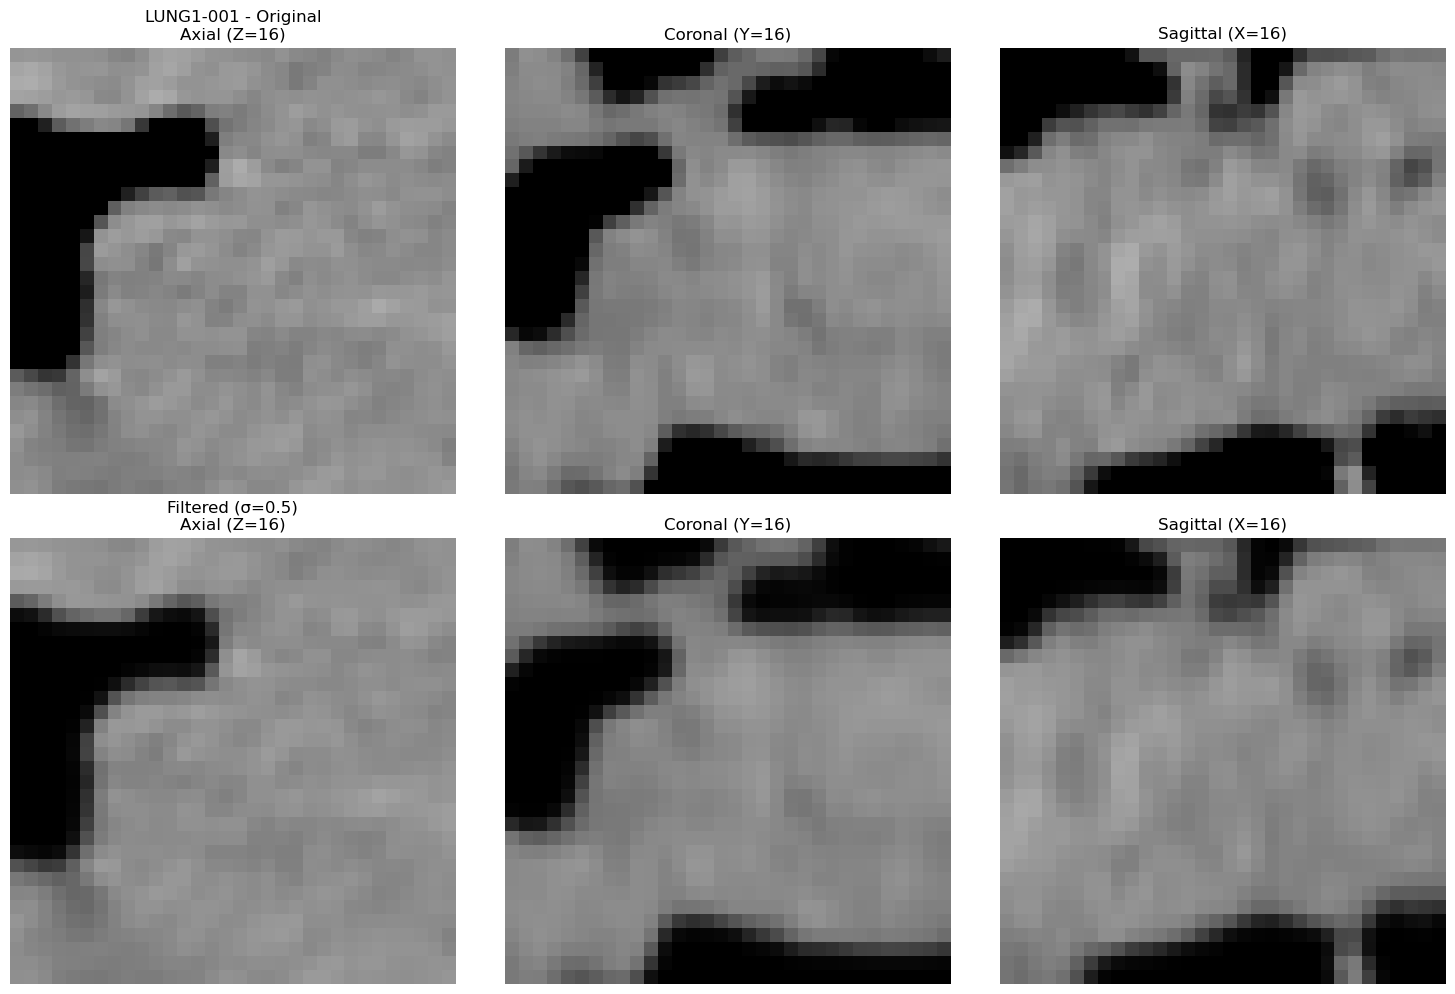


[6/6] Test Summary
✅ ALL TESTS PASSED!

📊 Results:
   Patient: LUNG1-001
   CT shape: (134, 512, 512)
   Spacing: (0.9765625, 0.9765625, 3.0)
   Tumor voxels: 54,639
   Tumor volume: 156323.4 mm³
   Centroid: (116, 258, 331)
   Connected components: 1
   Largest component: 100.0% of total
   Patch shape: (32, 32, 32)
   Value range: [0.000, 0.786]
   Mean ± Std: 0.416 ± 0.213
   Orientation check: ✅ OK

✅ Pipeline is working correctly!


In [5]:
#!/usr/bin/env python3
"""
STANDALONE Test - Patch Extraction Pipeline
============================================

File này chạy HOÀN TOÀN ĐỘC LẬP - không cần import file nào khác.
Test pipeline extract 32×32×32 patches theo Ferretti & Corino (2024).

Usage:
    python test_patch_extraction_standalone.py
"""

import os
import numpy as np
import pydicom
import scipy.ndimage as ndi
from scipy.ndimage import gaussian_filter, zoom
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "nsclc"
OUTPUT_DIR = "data_3d_ae"

# Ferretti & Corino (2024) parameters
TARGET_SPACING = [1.0, 1.0, 1.5]  # mm³
HU_WINDOW = [-250, 250]           # Hounsfield Units
PATCH_SIZE = 32                   # Extract 32×32×32 patch
GAUSSIAN_SIGMA = 0.5              # Gaussian filter sigma

# Note: We do NOT crop to fixed size (e.g., 128³)
# Instead, we resample then extract patch directly from tumor centroid

# ============================================================
# DICOM PROCESSING FUNCTIONS
# ============================================================

def slice_order_key(ds):
    """Determine CT slice order."""
    inst = getattr(ds, "InstanceNumber", None)
    if inst is not None:
        return float(inst)
    
    ipp = getattr(ds, "ImagePositionPatient", None)
    if ipp is not None and len(ipp) > 2:
        return float(ipp[2])
    
    return 0.0


def load_ct_volume(ct_dir):
    """
    Load CT DICOM series as 3D volume.
    
    Returns:
        ct_vol: 3D array (slices, rows, cols) in HU
        ct_dcms: List of DICOM datasets
        spacing: Tuple (pixel_spacing_x, pixel_spacing_y, slice_thickness)
    """
    ct_dir = Path(ct_dir)
    dcm_files = sorted(ct_dir.glob("*.dcm"))
    
    if not dcm_files:
        raise ValueError(f"No DICOM files found in {ct_dir}")
    
    # Read CT DICOMs
    ct_dcms = []
    for dcm_path in dcm_files:
        try:
            ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=False)
            if hasattr(ds, 'Modality') and ds.Modality == 'CT':
                ct_dcms.append(ds)
        except Exception:
            pass
    
    if not ct_dcms:
        raise ValueError(f"No valid CT DICOM files in {ct_dir}")
    
    # Sort by slice position
    ct_dcms.sort(key=slice_order_key)
    
    # Get spacing
    pixel_spacing = ct_dcms[0].PixelSpacing
    
    if len(ct_dcms) > 1:
        slice_thickness = getattr(ct_dcms[0], 'SliceThickness', None)
        if slice_thickness is None:
            pos1 = ct_dcms[0].ImagePositionPatient[2]
            pos2 = ct_dcms[1].ImagePositionPatient[2]
            slice_thickness = abs(pos2 - pos1)
    else:
        slice_thickness = 1.0
    
    spacing = (float(pixel_spacing[0]), float(pixel_spacing[1]), float(slice_thickness))
    
    # Stack slices
    ct_vol = np.stack([ds.pixel_array for ds in ct_dcms], axis=0)
    
    # Convert to HU
    if hasattr(ct_dcms[0], 'RescaleSlope') and hasattr(ct_dcms[0], 'RescaleIntercept'):
        slope = ct_dcms[0].RescaleSlope
        intercept = ct_dcms[0].RescaleIntercept
        ct_vol = ct_vol * slope + intercept
    
    # CRITICAL FIX: Clip ghost pixels (NSCLC-Radiomics has corrupted pixels at ±32768)
    # Clip BEFORE any processing to avoid extreme values
    ct_vol = np.clip(ct_vol, -1024, 3071)  # Standard CT range
    
    return ct_vol, ct_dcms, spacing


def get_segment_labels(seg_ds):
    """Extract segment labels from DICOM Segmentation."""
    segment_labels = {}
    
    if hasattr(seg_ds, 'SegmentSequence'):
        for segment in seg_ds.SegmentSequence:
            seg_num = segment.SegmentNumber
            label = getattr(segment, 'SegmentLabel', f'Segment_{seg_num}')
            segment_labels[seg_num] = label
    
    return segment_labels


def find_tumor_segment_number(seg_ds):
    """
    Auto-detect tumor segment number.
    
    Strategy:
    1. Look for tumor-related keywords
    2. If only 1 segment, use that
    3. Fallback to segment #2 (NSCLC-Radiomics convention)
    """
    if not hasattr(seg_ds, 'SegmentSequence'):
        raise ValueError("No SegmentSequence found")
    
    segments = seg_ds.SegmentSequence
    segment_labels = get_segment_labels(seg_ds)
    
    # If only one segment, use it
    if len(segments) == 1:
        return segments[0].SegmentNumber
    
    # Look for tumor keywords
    tumor_keywords = ['tumor', 'tumour', 'neoplasm', 'primary', 'gtv', 'cancer', 'mass', 'lesion']
    
    for segment in segments:
        seg_num = segment.SegmentNumber
        label = getattr(segment, 'SegmentLabel', '').lower()
        description = getattr(segment, 'SegmentDescription', '').lower()
        
        for keyword in tumor_keywords:
            if keyword in label or keyword in description:
                return seg_num
        
        if hasattr(segment, 'SegmentedPropertyTypeCodeSequence'):
            type_seq = segment.SegmentedPropertyTypeCodeSequence[0]
            type_meaning = getattr(type_seq, 'CodeMeaning', '').lower()
            for keyword in tumor_keywords:
                if keyword in type_meaning:
                    return seg_num
    
    # Fallback: segment #2 (NSCLC-Radiomics convention)
    if 2 in segment_labels:
        return 2
    
    # Last resort: first segment
    return segments[0].SegmentNumber


def load_segmentation(seg_file, ct_dcms, debug=False):
    """
    Load DICOM SEG and create 3D mask for TUMOR ONLY.
    
    Returns:
        mask: 3D binary array (slices, rows, cols)
    """
    seg_file = Path(seg_file)
    seg = pydicom.dcmread(str(seg_file))
    
    if seg.Modality != "SEG":
        raise ValueError(f"Not a DICOM SEG file. Modality: {seg.Modality}")
    
    # Get tumor segment
    segment_labels = get_segment_labels(seg)
    tumor_seg_num = find_tumor_segment_number(seg)
    
    if debug:
        print(f"    Segments: {segment_labels}")
        print(f"    Tumor segment: #{tumor_seg_num} - {segment_labels.get(tumor_seg_num, 'Unknown')}")
    
    # Read frames
    frames = seg.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]
    
    # Initialize mask
    num_slices = len(ct_dcms)
    rows = int(ct_dcms[0].Rows)
    cols = int(ct_dcms[0].Columns)
    mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)
    
    # Create SOP UID mapping
    sop_to_index = {ds.SOPInstanceUID: i for i, ds in enumerate(ct_dcms)}
    
    tumor_frames_mapped = 0
    
    # Map frames to slices
    if not hasattr(seg, 'PerFrameFunctionalGroupsSequence'):
        # Fallback: direct mapping
        if debug:
            print(f"    Using direct frame mapping")
        for frame_idx in range(min(len(frames), num_slices)):
            if frames[frame_idx].max() > 0:
                mask[frame_idx] = (frames[frame_idx] > 0).astype(np.uint8)
                tumor_frames_mapped += 1
    else:
        pffg = seg.PerFrameFunctionalGroupsSequence
        
        for frame_idx, frame_info in enumerate(pffg):
            if frame_idx >= len(frames):
                break
            
            # Get segment number for this frame
            frame_seg_num = None
            if hasattr(frame_info, 'SegmentIdentificationSequence'):
                if len(frame_info.SegmentIdentificationSequence) > 0:
                    frame_seg_num = frame_info.SegmentIdentificationSequence[0].ReferencedSegmentNumber
            
            # Process if tumor segment
            process_frame = (frame_seg_num is None or frame_seg_num == tumor_seg_num)
            
            if process_frame:
                ref_sop = None
                slice_idx = None
                
                # Method 1: DerivationImageSequence
                if hasattr(frame_info, 'DerivationImageSequence'):
                    if len(frame_info.DerivationImageSequence) > 0:
                        deriv = frame_info.DerivationImageSequence[0]
                        if hasattr(deriv, 'SourceImageSequence'):
                            if len(deriv.SourceImageSequence) > 0:
                                ref_image = deriv.SourceImageSequence[0]
                                ref_sop = ref_image.ReferencedSOPInstanceUID
                
                # Method 2: ReferencedImageSequence
                if ref_sop is None and hasattr(frame_info, 'ReferencedImageSequence'):
                    if len(frame_info.ReferencedImageSequence) > 0:
                        ref_image = frame_info.ReferencedImageSequence[0]
                        if hasattr(ref_image, 'ReferencedSOPInstanceUID'):
                            ref_sop = ref_image.ReferencedSOPInstanceUID
                
                # Method 3: PlanePositionSequence
                if ref_sop is None and hasattr(frame_info, 'PlanePositionSequence'):
                    if len(frame_info.PlanePositionSequence) > 0:
                        plane_pos = frame_info.PlanePositionSequence[0]
                        if hasattr(plane_pos, 'ImagePositionPatient'):
                            frame_ipp = plane_pos.ImagePositionPatient
                            for i, ct_ds in enumerate(ct_dcms):
                                if hasattr(ct_ds, 'ImagePositionPatient'):
                                    ct_ipp = ct_ds.ImagePositionPatient
                                    if all(abs(float(frame_ipp[j]) - float(ct_ipp[j])) < 0.1 for j in range(3)):
                                        slice_idx = i
                                        break
                
                # Map using SOP UID
                if ref_sop and ref_sop in sop_to_index:
                    slice_idx = sop_to_index[ref_sop]
                
                # Method 4: Direct index mapping
                if slice_idx is None and len(frames) == num_slices:
                    slice_idx = frame_idx
                
                # Apply mask
                if slice_idx is not None and slice_idx < num_slices:
                    if frames[frame_idx].max() > 0:
                        mask[slice_idx] = np.maximum(mask[slice_idx], (frames[frame_idx] > 0).astype(np.uint8))
                        tumor_frames_mapped += 1
    
    if debug:
        print(f"    Mapped {tumor_frames_mapped} tumor frames")
        print(f"    Total tumor voxels: {mask.sum():,}")
    
    if mask.sum() == 0:
        raise ValueError(f"No tumor voxels found for segment {tumor_seg_num}")
    
    return mask


# ============================================================
# PREPROCESSING FUNCTIONS
# ============================================================

def check_orientation_match(ct_dcms, seg_ds, debug=False):
    """
    Check if CT and Segmentation have matching orientation.
    
    CRITICAL for NSCLC-Radiomics: some SEG files have different orientation.
    """
    if not hasattr(ct_dcms[0], 'ImageOrientationPatient'):
        if debug:
            print("    Warning: CT missing ImageOrientationPatient")
        return True  # Assume OK if missing
    
    ct_orientation = ct_dcms[0].ImageOrientationPatient
    
    # SEG orientation is in SharedFunctionalGroupsSequence
    if hasattr(seg_ds, 'SharedFunctionalGroupsSequence'):
        if len(seg_ds.SharedFunctionalGroupsSequence) > 0:
            shared = seg_ds.SharedFunctionalGroupsSequence[0]
            if hasattr(shared, 'PlaneOrientationSequence'):
                if len(shared.PlaneOrientationSequence) > 0:
                    plane = shared.PlaneOrientationSequence[0]
                    if hasattr(plane, 'ImageOrientationPatient'):
                        seg_orientation = plane.ImageOrientationPatient
                        
                        # Check if orientations match (with small tolerance)
                        match = all(abs(float(ct_orientation[i]) - float(seg_orientation[i])) < 0.01 
                                  for i in range(6))
                        
                        if not match and debug:
                            print(f"    Warning: Orientation mismatch!")
                            print(f"    CT:  {ct_orientation}")
                            print(f"    SEG: {seg_orientation}")
                        
                        return match
    
    # If SEG orientation not found, assume OK
    return True


def resample_volume(volume, original_spacing, target_spacing, is_mask=False):
    """
    Resample volume to target spacing.
    
    Args:
        volume: 3D array to resample
        original_spacing: (x, y, z) spacing in mm
        target_spacing: (x, y, z) target spacing in mm
        is_mask: If True, use nearest neighbor (order=0) to preserve binary values
                 If False, use linear interpolation (order=1)
    """
    zoom_factors = [
        original_spacing[2] / target_spacing[2],  # Z
        original_spacing[0] / target_spacing[0],  # Y
        original_spacing[1] / target_spacing[1],  # X
    ]
    
    # Use order=0 (nearest neighbor) for masks to preserve binary values
    # Use order=1 (linear) for CT volumes
    order = 0 if is_mask else 1
    
    resampled = zoom(volume, zoom_factors, order=order)
    return resampled


def pad_or_crop_to_size(array, target_size):
    """
    Pad or crop 3D array to target size.
    
    NOTE: This function is NOT used in the main pipeline anymore.
    We extract patches directly from resampled volumes instead of
    cropping to fixed size first (which can lose tumor data).
    
    Kept for reference/debugging purposes only.
    """
    current_size = array.shape
    result = np.zeros(target_size, dtype=array.dtype)
    
    use_d = min(current_size[0], target_size[0])
    use_h = min(current_size[1], target_size[1])
    use_w = min(current_size[2], target_size[2])
    
    offset_d = (target_size[0] - use_d) // 2
    offset_h = (target_size[1] - use_h) // 2
    offset_w = (target_size[2] - use_w) // 2
    
    result[
        offset_d:offset_d+use_d,
        offset_h:offset_h+use_h,
        offset_w:offset_w+use_w
    ] = array[:use_d, :use_h, :use_w]
    
    return result


def get_tumor_centroid(mask):
    """
    Get centroid of LARGEST CONNECTED COMPONENT in tumor mask.
    
    This prevents centroid shifting when tumor is elongated or has multiple disconnected regions.
    """
    coords = np.where(mask > 0)
    
    if len(coords[0]) == 0:
        raise ValueError("Empty tumor mask")
    
    # Find largest connected component
    labeled, n_components = ndi.label(mask)
    
    if n_components == 0:
        raise ValueError("No connected components found in mask")
    
    # Get size of each component
    component_sizes = ndi.sum(mask, labeled, range(n_components + 1))
    
    # Find largest component (skip background at index 0)
    largest_component = np.argmax(component_sizes[1:]) + 1
    
    # Get coordinates of largest component only
    coords_largest = np.where(labeled == largest_component)
    
    centroid = (
        int(np.mean(coords_largest[0])),
        int(np.mean(coords_largest[1])),
        int(np.mean(coords_largest[2]))
    )
    
    # Log info about connected components
    total_voxels = len(coords[0])
    largest_voxels = int(component_sizes[largest_component])
    
    return centroid, {
        'n_components': n_components,
        'total_voxels': total_voxels,
        'largest_component_voxels': largest_voxels,
        'largest_component_ratio': largest_voxels / total_voxels if total_voxels > 0 else 0
    }


def extract_patch(volume, centroid, patch_size=32):
    """Extract patch centered on centroid."""
    half = patch_size // 2
    z, y, x = centroid
    
    z_start = max(0, z - half)
    z_end = min(volume.shape[0], z + half)
    y_start = max(0, y - half)
    y_end = min(volume.shape[1], y + half)
    x_start = max(0, x - half)
    x_end = min(volume.shape[2], x + half)
    
    extracted = volume[z_start:z_end, y_start:y_end, x_start:x_end]
    
    if extracted.shape != (patch_size, patch_size, patch_size):
        patch = np.zeros((patch_size, patch_size, patch_size), dtype=extracted.dtype)
        
        pad_z = (patch_size - extracted.shape[0]) // 2
        pad_y = (patch_size - extracted.shape[1]) // 2
        pad_x = (patch_size - extracted.shape[2]) // 2
        
        patch[
            pad_z:pad_z+extracted.shape[0],
            pad_y:pad_y+extracted.shape[1],
            pad_x:pad_x+extracted.shape[2]
        ] = extracted
    else:
        patch = extracted
    
    return patch


def preprocess_patient(ct_dir, seg_file, debug=False):
    """
    Full preprocessing pipeline for one patient.
    
    Returns:
        patch_orig: 32×32×32 original patch
        patch_filt: 32×32×32 Gaussian filtered patch
        centroid: (z, y, x) tumor centroid
        metadata: Dictionary with processing info
    """
    # 1. Load CT volume
    ct_vol, ct_dcms, spacing = load_ct_volume(ct_dir)
    if debug:
        print(f"    Step 1: Loaded CT - shape {ct_vol.shape}, spacing {spacing}")
    
    # 2. Load segmentation (tumor only)
    seg_ds = pydicom.dcmread(seg_file)
    
    # CHECK ORIENTATION (CRITICAL FIX)
    orientation_ok = check_orientation_match(ct_dcms, seg_ds, debug=debug)
    if not orientation_ok:
        raise ValueError(f"CT and SEG orientation mismatch! Check ImageOrientationPatient.")
    
    mask = load_segmentation(seg_file, ct_dcms, debug=debug)
    if debug:
        print(f"    Step 2: Loaded mask - shape {mask.shape}, tumor voxels: {mask.sum():,}")
    
    # Calculate original tumor volume in mm³
    voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]
    tumor_volume_mm3 = mask.sum() * voxel_volume_mm3
    
    # 3. Resample to target spacing
    ct_resampled = resample_volume(ct_vol, spacing, TARGET_SPACING, is_mask=False)
    mask_resampled = resample_volume(mask.astype(np.float32), spacing, TARGET_SPACING, is_mask=True)
    
    # Convert mask back to binary
    mask_resampled = (mask_resampled > 0).astype(np.uint8)
    
    if debug:
        print(f"    Step 3: Resampled - CT {ct_resampled.shape}, mask tumor voxels: {mask_resampled.sum():,}")
    
    # 4. Get tumor centroid (on resampled volume, NOT cropped)
    centroid, centroid_info = get_tumor_centroid(mask_resampled)
    
    if debug:
        print(f"    Step 4: Tumor centroid at {centroid}")
        print(f"            Connected components: {centroid_info['n_components']}")
        print(f"            Largest component: {centroid_info['largest_component_voxels']:,}/{centroid_info['total_voxels']:,} voxels ({centroid_info['largest_component_ratio']:.1%})")
    
    # 5. Clip HU values
    ct_resampled = np.clip(ct_resampled, HU_WINDOW[0], HU_WINDOW[1])
    
    # 6. Rescale to [0, 1]
    ct_resampled = (ct_resampled - HU_WINDOW[0]) / (HU_WINDOW[1] - HU_WINDOW[0])
    
    if debug:
        print(f"    Step 5-6: Clipped & rescaled - CT range [{ct_resampled.min():.3f}, {ct_resampled.max():.3f}]")
    
    # 7. Extract 32×32×32 patch centered on tumor (DIRECTLY from resampled volume)
    patch = extract_patch(ct_resampled, centroid, PATCH_SIZE)
    
    if debug:
        print(f"    Step 7: Extracted {PATCH_SIZE}³ patch centered at {centroid}")
    
    # 8. Apply Gaussian filter
    patch_filtered = gaussian_filter(patch, sigma=GAUSSIAN_SIGMA)
    
    if debug:
        print(f"    Step 8: Applied Gaussian filter (σ={GAUSSIAN_SIGMA})")
    
    # Create metadata
    metadata = {
        'original_shape': list(ct_vol.shape),
        'original_spacing_mm': list(spacing),
        'target_spacing_mm': TARGET_SPACING,
        'resampled_shape': list(ct_resampled.shape),
        'tumor_volume_mm3': float(tumor_volume_mm3),
        'tumor_voxels_original': int(mask.sum()),
        'tumor_voxels_resampled': int(mask_resampled.sum()),
        'centroid': list(centroid),
        'centroid_info': centroid_info,
        'patch_size': PATCH_SIZE,
        'gaussian_sigma': GAUSSIAN_SIGMA,
        'hu_window': HU_WINDOW,
        'patch_mean': float(patch.mean()),
        'patch_std': float(patch.std()),
        'patch_min': float(patch.min()),
        'patch_max': float(patch.max()),
        'orientation_ok': orientation_ok
    }
    
    return patch.astype(np.float32), patch_filtered.astype(np.float32), centroid, metadata


# ============================================================
# FIND PATIENTS
# ============================================================

def find_patient_data(data_dir):
    """Find all patient folders with CT and SEG data."""
    data_dir = Path(data_dir)
    
    print(f"Searching for data in: {data_dir}")
    
    # Navigate to NSCLC-Radiomics folder
    if data_dir.name != "NSCLC-Radiomics":
        manifest_folders = list(data_dir.glob("manifest-*/NSCLC-Radiomics"))
        
        if manifest_folders:
            data_dir = manifest_folders[0]
            print(f"  → Found: {data_dir}")
        else:
            if (data_dir / "NSCLC-Radiomics").exists():
                data_dir = data_dir / "NSCLC-Radiomics"
                print(f"  → Found: {data_dir}")
    
    patient_folders = sorted(data_dir.glob("LUNG1-*"))
    print(f"  → Found {len(patient_folders)} patient folders")
    
    if len(patient_folders) == 0:
        return []
    
    patient_data = []
    
    for patient_folder in patient_folders:
        patient_id = patient_folder.name
        study_folders = [f for f in patient_folder.iterdir() if f.is_dir()]
        
        if not study_folders:
            continue
        
        study_folder = study_folders[0]
        ct_dir = None
        seg_dir = None
        
        for series_folder in study_folder.iterdir():
            if not series_folder.is_dir():
                continue
            
            series_name = series_folder.name
            
            if series_name.startswith("300."):
                seg_dir = series_folder
            else:
                dcm_count = len(list(series_folder.glob("*.dcm")))
                if dcm_count > 0:
                    if ct_dir is None:
                        ct_dir = series_folder
                    else:
                        current_count = len(list(ct_dir.glob("*.dcm")))
                        if dcm_count > current_count:
                            ct_dir = series_folder
        
        if ct_dir is None or seg_dir is None:
            continue
        
        seg_files = list(seg_dir.glob("*.dcm"))
        if not seg_files:
            continue
        
        seg_file = seg_files[0]
        
        patient_data.append({
            "patient_id": patient_id,
            "patient_dir": patient_folder,
            "ct_dir": ct_dir,
            "seg_file": seg_file
        })
    
    return patient_data


# ============================================================
# TEST FUNCTIONS
# ============================================================

def test_single_patient(patient_id=None):
    """Test pipeline với 1 patient."""
    
    print("="*80)
    print("TEST PATCH EXTRACTION PIPELINE - STANDALONE")
    print("="*80)
    
    # 1. Find patients
    print(f"\n[1/6] Finding patients in {DATA_DIR}...")
    patient_data_list = find_patient_data(DATA_DIR)
    
    if len(patient_data_list) == 0:
        print("❌ No patients found!")
        return False
    
    print(f"✅ Found {len(patient_data_list)} patients")
    
    # Select patient
    if patient_id is None:
        patient = patient_data_list[0]
        print(f"📌 Using first patient: {patient['patient_id']}")
    else:
        patient = next((p for p in patient_data_list if p['patient_id'] == patient_id), None)
        if patient is None:
            print(f"❌ Patient {patient_id} not found!")
            return False
    
    patient_id = patient['patient_id']
    
    # 2. Load CT
    print(f"\n[2/6] Loading CT volume for {patient_id}...")
    try:
        ct_vol, ct_dcms, spacing = load_ct_volume(patient['ct_dir'])
        print(f"✅ CT loaded:")
        print(f"   Shape: {ct_vol.shape}")
        print(f"   Spacing: {spacing}")
        print(f"   HU range: [{ct_vol.min():.1f}, {ct_vol.max():.1f}]")
    except Exception as e:
        print(f"❌ Failed to load CT: {e}")
        return False
    
    # 3. Load segmentation
    print(f"\n[3/6] Loading segmentation...")
    try:
        seg_ds = pydicom.dcmread(patient['seg_file'])
        segment_labels = get_segment_labels(seg_ds)
        tumor_seg_num = find_tumor_segment_number(seg_ds)
        
        print(f"✅ Segmentation loaded:")
        print(f"   Total segments: {len(segment_labels)}")
        for seg_num, label in segment_labels.items():
            marker = " ← TUMOR" if seg_num == tumor_seg_num else ""
            print(f"   #{seg_num}: {label}{marker}")
        
        mask = load_segmentation(patient['seg_file'], ct_dcms, debug=True)
        print(f"✅ Mask created:")
        print(f"   Shape: {mask.shape}")
        print(f"   Tumor voxels: {mask.sum():,}")
        
        if mask.sum() == 0:
            print("❌ No tumor voxels found!")
            return False
            
    except Exception as e:
        print(f"❌ Failed to load segmentation: {e}")
        import traceback
        traceback.print_exc()
        return False
    
    # 4. Preprocess
    print(f"\n[4/6] Running preprocessing pipeline...")
    try:
        patch_orig, patch_filt, centroid, metadata = preprocess_patient(
            patient['ct_dir'], 
            patient['seg_file'],
            debug=True
        )
        
        print(f"✅ Preprocessing complete:")
        print(f"   Patch shape: {patch_orig.shape}")
        print(f"   Centroid: {centroid}")
        print(f"   Original patch:")
        print(f"     Min: {patch_orig.min():.4f}")
        print(f"     Max: {patch_orig.max():.4f}")
        print(f"     Mean: {patch_orig.mean():.4f}")
        print(f"     Std: {patch_orig.std():.4f}")
        print(f"   Filtered patch:")
        print(f"     Min: {patch_filt.min():.4f}")
        print(f"     Max: {patch_filt.max():.4f}")
        print(f"     Mean: {patch_filt.mean():.4f}")
        print(f"     Std: {patch_filt.std():.4f}")
        print(f"   Tumor volume: {metadata['tumor_volume_mm3']:.1f} mm³")
        print(f"   Connected components: {metadata['centroid_info']['n_components']}")
        
        # Check for NaN/Inf
        if np.isnan(patch_orig).any() or np.isinf(patch_orig).any():
            print("⚠️  WARNING: NaN or Inf values detected in original patch!")
        if np.isnan(patch_filt).any() or np.isinf(patch_filt).any():
            print("⚠️  WARNING: NaN or Inf values detected in filtered patch!")
        
        # Save metadata
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        metadata_file = Path(OUTPUT_DIR) / f"test_metadata_{patient_id}.json"
        metadata['patient_id'] = patient_id
        
        import json
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"   Metadata saved: {metadata_file}")
            
    except Exception as e:
        print(f"❌ Preprocessing failed: {e}")
        import traceback
        traceback.print_exc()
        return False
    
    # 5. Visualize
    print(f"\n[5/6] Creating visualization...")
    try:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Original patch - 3 orthogonal slices
        axes[0, 0].imshow(patch_orig[16, :, :], cmap='gray', vmin=0, vmax=1)
        axes[0, 0].set_title(f'{patient_id} - Original\nAxial (Z=16)')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(patch_orig[:, 16, :], cmap='gray', vmin=0, vmax=1)
        axes[0, 1].set_title('Coronal (Y=16)')
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(patch_orig[:, :, 16], cmap='gray', vmin=0, vmax=1)
        axes[0, 2].set_title('Sagittal (X=16)')
        axes[0, 2].axis('off')
        
        # Filtered patch - 3 orthogonal slices
        axes[1, 0].imshow(patch_filt[16, :, :], cmap='gray', vmin=0, vmax=1)
        axes[1, 0].set_title('Filtered (σ=0.5)\nAxial (Z=16)')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(patch_filt[:, 16, :], cmap='gray', vmin=0, vmax=1)
        axes[1, 1].set_title('Coronal (Y=16)')
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(patch_filt[:, :, 16], cmap='gray', vmin=0, vmax=1)
        axes[1, 2].set_title('Sagittal (X=16)')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        
        # Save
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        output_file = Path(OUTPUT_DIR) / f"test_patch_{patient_id}.png"
        plt.savefig(output_file, dpi=150, bbox_inches='tight')
        print(f"✅ Visualization saved: {output_file}")
        
        try:
            plt.show()
        except:
            pass
        
        plt.close()
        
    except Exception as e:
        print(f"⚠️  Visualization failed: {e}")
    
    # 6. Summary
    print(f"\n[6/6] Test Summary")
    print("="*80)
    print("✅ ALL TESTS PASSED!")
    print("\n📊 Results:")
    print(f"   Patient: {patient_id}")
    print(f"   CT shape: {ct_vol.shape}")
    print(f"   Spacing: {spacing}")
    print(f"   Tumor voxels: {mask.sum():,}")
    print(f"   Tumor volume: {metadata['tumor_volume_mm3']:.1f} mm³")
    print(f"   Centroid: {centroid}")
    print(f"   Connected components: {metadata['centroid_info']['n_components']}")
    print(f"   Largest component: {metadata['centroid_info']['largest_component_ratio']:.1%} of total")
    print(f"   Patch shape: {patch_orig.shape}")
    print(f"   Value range: [{patch_orig.min():.3f}, {patch_orig.max():.3f}]")
    print(f"   Mean ± Std: {patch_orig.mean():.3f} ± {patch_orig.std():.3f}")
    print(f"   Orientation check: {'✅ OK' if metadata['orientation_ok'] else '⚠️  MISMATCH'}")
    print("\n✅ Pipeline is working correctly!")
    print("="*80)
    
    return True


def quick_test_multiple_patients(n=5):
    """Quick test cho nhiều patients."""
    
    print("="*80)
    print(f"QUICK TEST - {n} PATIENTS")
    print("="*80)
    
    patient_data_list = find_patient_data(DATA_DIR)
    
    if len(patient_data_list) == 0:
        print("❌ No patients found!")
        return
    
    n = min(n, len(patient_data_list))
    print(f"\nTesting {n} patients...\n")
    
    results = []
    
    for i, patient in enumerate(patient_data_list[:n], 1):
        patient_id = patient['patient_id']
        print(f"[{i}/{n}] {patient_id}...", end=" ")
        
        try:
            patch_orig, patch_filt, centroid, metadata = preprocess_patient(
                patient['ct_dir'],
                patient['seg_file'],
                debug=False
            )
            
            # Quick validation
            valid = True
            issues = []
            
            if patch_orig.shape != (32, 32, 32):
                issues.append(f"Wrong shape: {patch_orig.shape}")
                valid = False
            
            if np.isnan(patch_orig).any() or np.isinf(patch_orig).any():
                issues.append("NaN/Inf detected")
                valid = False
            
            if patch_orig.min() < 0 or patch_orig.max() > 1:
                issues.append(f"Out of range: [{patch_orig.min():.3f}, {patch_orig.max():.3f}]")
                valid = False
            
            if valid:
                print(f"✅ OK (mean={patch_orig.mean():.3f}, components={metadata['centroid_info']['n_components']})")
            else:
                print(f"❌ {', '.join(issues)}")
            
            results.append({
                'patient_id': patient_id,
                'success': valid,
                'mean': patch_orig.mean() if valid else None,
                'metadata': metadata if valid else None
            })
            
        except Exception as e:
            print(f"❌ FAILED: {str(e)[:50]}")
            results.append({
                'patient_id': patient_id,
                'success': False,
                'error': str(e)
            })
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    
    successful = sum(1 for r in results if r['success'])
    print(f"Successful: {successful}/{n}")
    
    if successful == n:
        print("\n✅ ALL TESTS PASSED!")
        print("\n🚀 Ready for full processing!")
    else:
        print(f"\n⚠️  {n - successful} patients failed")
        print("\nFailed patients:")
        for r in results:
            if not r['success']:
                error = r.get('error', 'Validation failed')
                print(f"  - {r['patient_id']}: {error[:60]}")
    
    print("="*80)


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
#     import argparse
    
#     parser = argparse.ArgumentParser(description='Test patch extraction pipeline (standalone)')
#     parser.add_argument('--patient', type=str, default=None, 
#                        help='Patient ID to test (default: first patient)')
#     parser.add_argument('--quick', type=int, default=None,
#                        help='Quick test N patients')
    
#     args = parser.parse_args()
    
#     if args.quick:
#         quick_test_multiple_patients(args.quick)
#     else:
#         test_single_patient(args.patient)
    test_single_patient("LUNG1-001")

In [6]:
#!/usr/bin/env python3
"""
Parallel Patch Extraction Pipeline - All Patients
==================================================

Chạy toàn bộ bệnh nhân song song trên 9 CPU cores.
Extract 32×32×32 patches theo Ferretti & Corino (2024).

Usage:
    python extract_all_patients_parallel.py
"""

import os
import numpy as np
import pydicom
import scipy.ndimage as ndi
from scipy.ndimage import gaussian_filter, zoom
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
import json
from datetime import datetime
from multiprocessing import Pool
import traceback

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "nsclc"
OUTPUT_DIR = "data_3d_ae_parallel"

# Ferretti & Corino (2024) parameters
TARGET_SPACING = [1.0, 1.0, 1.5]  # mm³
HU_WINDOW = [-250, 250]           # Hounsfield Units
PATCH_SIZE = 32                   # Extract 32×32×32 patch
GAUSSIAN_SIGMA = 0.5              # Gaussian filter sigma

N_WORKERS = 9  # Number of parallel workers

# ============================================================
# DICOM PROCESSING FUNCTIONS
# ============================================================

def slice_order_key(ds):
    """Determine CT slice order."""
    inst = getattr(ds, "InstanceNumber", None)
    if inst is not None:
        return float(inst)

    ipp = getattr(ds, "ImagePositionPatient", None)
    if ipp is not None and len(ipp) > 2:
        return float(ipp[2])

    return 0.0


def load_ct_volume(ct_dir):
    """
    Load CT DICOM series as 3D volume.

    Returns:
        ct_vol: 3D array (slices, rows, cols) in HU
        ct_dcms: List of DICOM datasets
        spacing: Tuple (pixel_spacing_x, pixel_spacing_y, slice_thickness)
    """
    ct_dir = Path(ct_dir)
    dcm_files = sorted(ct_dir.glob("*.dcm"))

    if not dcm_files:
        raise ValueError(f"No DICOM files found in {ct_dir}")

    # Read CT DICOMs
    ct_dcms = []
    for dcm_path in dcm_files:
        try:
            ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=False)
            if hasattr(ds, 'Modality') and ds.Modality == 'CT':
                ct_dcms.append(ds)
        except Exception:
            pass

    if not ct_dcms:
        raise ValueError(f"No valid CT DICOM files in {ct_dir}")

    # Sort by slice position
    ct_dcms.sort(key=slice_order_key)

    # Get spacing
    pixel_spacing = ct_dcms[0].PixelSpacing

    if len(ct_dcms) > 1:
        slice_thickness = getattr(ct_dcms[0], 'SliceThickness', None)
        if slice_thickness is None:
            pos1 = ct_dcms[0].ImagePositionPatient[2]
            pos2 = ct_dcms[1].ImagePositionPatient[2]
            slice_thickness = abs(pos2 - pos1)
    else:
        slice_thickness = 1.0

    spacing = (float(pixel_spacing[0]), float(pixel_spacing[1]), float(slice_thickness))

    # Stack slices
    ct_vol = np.stack([ds.pixel_array for ds in ct_dcms], axis=0)

    # Convert to HU
    if hasattr(ct_dcms[0], 'RescaleSlope') and hasattr(ct_dcms[0], 'RescaleIntercept'):
        slope = ct_dcms[0].RescaleSlope
        intercept = ct_dcms[0].RescaleIntercept
        ct_vol = ct_vol * slope + intercept

    # CRITICAL FIX: Clip ghost pixels (NSCLC-Radiomics has corrupted pixels at ±32768)
    ct_vol = np.clip(ct_vol, -1024, 3071)  # Standard CT range

    return ct_vol, ct_dcms, spacing


def get_segment_labels(seg_ds):
    """Extract segment labels from DICOM Segmentation."""
    segment_labels = {}

    if hasattr(seg_ds, 'SegmentSequence'):
        for segment in seg_ds.SegmentSequence:
            seg_num = segment.SegmentNumber
            label = getattr(segment, 'SegmentLabel', f'Segment_{seg_num}')
            segment_labels[seg_num] = label

    return segment_labels


def find_tumor_segment_number(seg_ds):
    """
    Auto-detect tumor segment number.

    Strategy:
    1. Look for tumor-related keywords
    2. If only 1 segment, use that
    3. Fallback to segment #2 (NSCLC-Radiomics convention)
    """
    if not hasattr(seg_ds, 'SegmentSequence'):
        raise ValueError("No SegmentSequence found")

    segments = seg_ds.SegmentSequence
    segment_labels = get_segment_labels(seg_ds)

    # If only one segment, use it
    if len(segments) == 1:
        return segments[0].SegmentNumber

    # Look for tumor keywords
    tumor_keywords = ['tumor', 'tumour', 'neoplasm', 'primary', 'gtv', 'cancer', 'mass', 'lesion']

    for segment in segments:
        seg_num = segment.SegmentNumber
        label = getattr(segment, 'SegmentLabel', '').lower()
        description = getattr(segment, 'SegmentDescription', '').lower()

        for keyword in tumor_keywords:
            if keyword in label or keyword in description:
                return seg_num

        if hasattr(segment, 'SegmentedPropertyTypeCodeSequence'):
            type_seq = segment.SegmentedPropertyTypeCodeSequence[0]
            type_meaning = getattr(type_seq, 'CodeMeaning', '').lower()
            for keyword in tumor_keywords:
                if keyword in type_meaning:
                    return seg_num

    # Fallback: segment #2 (NSCLC-Radiomics convention)
    if 2 in segment_labels:
        return 2

    # Last resort: first segment
    return segments[0].SegmentNumber


def load_segmentation(seg_file, ct_dcms):
    """
    Load DICOM SEG and create 3D mask for TUMOR ONLY.

    Returns:
        mask: 3D binary array (slices, rows, cols)
    """
    seg_file = Path(seg_file)
    seg = pydicom.dcmread(str(seg_file))

    if seg.Modality != "SEG":
        raise ValueError(f"Not a DICOM SEG file. Modality: {seg.Modality}")

    # Get tumor segment
    segment_labels = get_segment_labels(seg)
    tumor_seg_num = find_tumor_segment_number(seg)

    # Read frames
    frames = seg.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]

    # Initialize mask
    num_slices = len(ct_dcms)
    rows = int(ct_dcms[0].Rows)
    cols = int(ct_dcms[0].Columns)
    mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)

    # Create SOP UID mapping
    sop_to_index = {ds.SOPInstanceUID: i for i, ds in enumerate(ct_dcms)}

    # Map frames to slices
    if not hasattr(seg, 'PerFrameFunctionalGroupsSequence'):
        # Fallback: direct mapping
        for frame_idx in range(min(len(frames), num_slices)):
            if frames[frame_idx].max() > 0:
                mask[frame_idx] = (frames[frame_idx] > 0).astype(np.uint8)
    else:
        pffg = seg.PerFrameFunctionalGroupsSequence

        for frame_idx, frame_info in enumerate(pffg):
            if frame_idx >= len(frames):
                break

            # Get segment number for this frame
            frame_seg_num = None
            if hasattr(frame_info, 'SegmentIdentificationSequence'):
                if len(frame_info.SegmentIdentificationSequence) > 0:
                    frame_seg_num = frame_info.SegmentIdentificationSequence[0].ReferencedSegmentNumber

            # Process if tumor segment
            process_frame = (frame_seg_num is None or frame_seg_num == tumor_seg_num)

            if process_frame:
                ref_sop = None
                slice_idx = None

                # Method 1: DerivationImageSequence
                if hasattr(frame_info, 'DerivationImageSequence'):
                    if len(frame_info.DerivationImageSequence) > 0:
                        deriv = frame_info.DerivationImageSequence[0]
                        if hasattr(deriv, 'SourceImageSequence'):
                            if len(deriv.SourceImageSequence) > 0:
                                ref_image = deriv.SourceImageSequence[0]
                                ref_sop = ref_image.ReferencedSOPInstanceUID

                # Method 2: ReferencedImageSequence
                if ref_sop is None and hasattr(frame_info, 'ReferencedImageSequence'):
                    if len(frame_info.ReferencedImageSequence) > 0:
                        ref_image = frame_info.ReferencedImageSequence[0]
                        if hasattr(ref_image, 'ReferencedSOPInstanceUID'):
                            ref_sop = ref_image.ReferencedSOPInstanceUID

                # Method 3: PlanePositionSequence
                if ref_sop is None and hasattr(frame_info, 'PlanePositionSequence'):
                    if len(frame_info.PlanePositionSequence) > 0:
                        plane_pos = frame_info.PlanePositionSequence[0]
                        if hasattr(plane_pos, 'ImagePositionPatient'):
                            frame_ipp = plane_pos.ImagePositionPatient
                            for i, ct_ds in enumerate(ct_dcms):
                                if hasattr(ct_ds, 'ImagePositionPatient'):
                                    ct_ipp = ct_ds.ImagePositionPatient
                                    if all(abs(float(frame_ipp[j]) - float(ct_ipp[j])) < 0.1 for j in range(3)):
                                        slice_idx = i
                                        break

                # Map using SOP UID
                if ref_sop and ref_sop in sop_to_index:
                    slice_idx = sop_to_index[ref_sop]

                # Method 4: Direct index mapping
                if slice_idx is None and len(frames) == num_slices:
                    slice_idx = frame_idx

                # Apply mask
                if slice_idx is not None and slice_idx < num_slices:
                    if frames[frame_idx].max() > 0:
                        mask[slice_idx] = np.maximum(mask[slice_idx], (frames[frame_idx] > 0).astype(np.uint8))

    if mask.sum() == 0:
        raise ValueError(f"No tumor voxels found for segment {tumor_seg_num}")

    return mask


def check_orientation_match(ct_dcms, seg_ds):
    """
    Check if CT and Segmentation have matching orientation.
    CRITICAL for NSCLC-Radiomics.
    """
    if not hasattr(ct_dcms[0], 'ImageOrientationPatient'):
        return True  # Assume OK if missing

    ct_orientation = ct_dcms[0].ImageOrientationPatient

    # SEG orientation is in SharedFunctionalGroupsSequence
    if hasattr(seg_ds, 'SharedFunctionalGroupsSequence'):
        if len(seg_ds.SharedFunctionalGroupsSequence) > 0:
            shared = seg_ds.SharedFunctionalGroupsSequence[0]
            if hasattr(shared, 'PlaneOrientationSequence'):
                if len(shared.PlaneOrientationSequence) > 0:
                    plane = shared.PlaneOrientationSequence[0]
                    if hasattr(plane, 'ImageOrientationPatient'):
                        seg_orientation = plane.ImageOrientationPatient

                        # Check if orientations match
                        match = all(abs(float(ct_orientation[i]) - float(seg_orientation[i])) < 0.01
                                  for i in range(6))

                        return match

    return True


# ============================================================
# PREPROCESSING FUNCTIONS
# ============================================================

def resample_volume(volume, original_spacing, target_spacing, is_mask=False):
    """Resample volume to target spacing."""
    zoom_factors = [
        original_spacing[2] / target_spacing[2],  # Z
        original_spacing[0] / target_spacing[0],  # Y
        original_spacing[1] / target_spacing[1],  # X
    ]

    order = 0 if is_mask else 1
    resampled = zoom(volume, zoom_factors, order=order)
    return resampled


def get_tumor_centroid(mask):
    """
    Get centroid of LARGEST CONNECTED COMPONENT in tumor mask.
    """
    coords = np.where(mask > 0)

    if len(coords[0]) == 0:
        raise ValueError("Empty tumor mask")

    # Find largest connected component
    labeled, n_components = ndi.label(mask)

    if n_components == 0:
        raise ValueError("No connected components found in mask")

    # Get size of each component
    component_sizes = ndi.sum(mask, labeled, range(n_components + 1))

    # Find largest component (skip background at index 0)
    largest_component = np.argmax(component_sizes[1:]) + 1

    # Get coordinates of largest component only
    coords_largest = np.where(labeled == largest_component)

    centroid = (
        int(np.mean(coords_largest[0])),
        int(np.mean(coords_largest[1])),
        int(np.mean(coords_largest[2]))
    )

    total_voxels = len(coords[0])
    largest_voxels = int(component_sizes[largest_component])

    return centroid, {
        'n_components': n_components,
        'total_voxels': total_voxels,
        'largest_component_voxels': largest_voxels,
        'largest_component_ratio': largest_voxels / total_voxels if total_voxels > 0 else 0
    }


def extract_patch(volume, centroid, patch_size=32):
    """Extract patch centered on centroid."""
    half = patch_size // 2
    z, y, x = centroid

    z_start = max(0, z - half)
    z_end = min(volume.shape[0], z + half)
    y_start = max(0, y - half)
    y_end = min(volume.shape[1], y + half)
    x_start = max(0, x - half)
    x_end = min(volume.shape[2], x + half)

    extracted = volume[z_start:z_end, y_start:y_end, x_start:x_end]

    if extracted.shape != (patch_size, patch_size, patch_size):
        patch = np.zeros((patch_size, patch_size, patch_size), dtype=extracted.dtype)

        pad_z = (patch_size - extracted.shape[0]) // 2
        pad_y = (patch_size - extracted.shape[1]) // 2
        pad_x = (patch_size - extracted.shape[2]) // 2

        patch[
            pad_z:pad_z+extracted.shape[0],
            pad_y:pad_y+extracted.shape[1],
            pad_x:pad_x+extracted.shape[2]
        ] = extracted
    else:
        patch = extracted

    return patch


def preprocess_patient(ct_dir, seg_file):
    """
    Full preprocessing pipeline for one patient.

    Returns:
        patch_orig: 32×32×32 original patch
        patch_filt: 32×32×32 Gaussian filtered patch
        centroid: (z, y, x) tumor centroid
        metadata: Dictionary with processing info
    """
    # 1. Load CT volume
    ct_vol, ct_dcms, spacing = load_ct_volume(ct_dir)

    # 2. Load segmentation (tumor only)
    seg_ds = pydicom.dcmread(seg_file)

    # CHECK ORIENTATION
    orientation_ok = check_orientation_match(ct_dcms, seg_ds)
    if not orientation_ok:
        raise ValueError("CT and SEG orientation mismatch")

    mask = load_segmentation(seg_file, ct_dcms)

    # Calculate original tumor volume
    voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]
    tumor_volume_mm3 = mask.sum() * voxel_volume_mm3

    # 3. Resample to target spacing
    ct_resampled = resample_volume(ct_vol, spacing, TARGET_SPACING, is_mask=False)
    mask_resampled = resample_volume(mask.astype(np.float32), spacing, TARGET_SPACING, is_mask=True)
    mask_resampled = (mask_resampled > 0).astype(np.uint8)

    # 4. Get tumor centroid
    centroid, centroid_info = get_tumor_centroid(mask_resampled)

    # 5. Clip HU values
    ct_resampled = np.clip(ct_resampled, HU_WINDOW[0], HU_WINDOW[1])

    # 6. Rescale to [0, 1]
    ct_resampled = (ct_resampled - HU_WINDOW[0]) / (HU_WINDOW[1] - HU_WINDOW[0])

    # 7. Extract patch
    patch = extract_patch(ct_resampled, centroid, PATCH_SIZE)

    # 8. Apply Gaussian filter
    patch_filtered = gaussian_filter(patch, sigma=GAUSSIAN_SIGMA)

    # Create metadata
    metadata = {
        'original_shape': list(ct_vol.shape),
        'original_spacing_mm': list(spacing),
        'target_spacing_mm': TARGET_SPACING,
        'resampled_shape': list(ct_resampled.shape),
        'tumor_volume_mm3': float(tumor_volume_mm3),
        'tumor_voxels_original': int(mask.sum()),
        'tumor_voxels_resampled': int(mask_resampled.sum()),
        'centroid': list(centroid),
        'centroid_info': centroid_info,
        'patch_size': PATCH_SIZE,
        'gaussian_sigma': GAUSSIAN_SIGMA,
        'hu_window': HU_WINDOW,
        'patch_mean': float(patch.mean()),
        'patch_std': float(patch.std()),
        'patch_min': float(patch.min()),
        'patch_max': float(patch.max()),
        'orientation_ok': orientation_ok
    }

    return patch.astype(np.float32), patch_filtered.astype(np.float32), centroid, metadata


# ============================================================
# FIND PATIENTS
# ============================================================

def find_patient_data(data_dir):
    """Find all patient folders with CT and SEG data."""
    data_dir = Path(data_dir)

    # Navigate to NSCLC-Radiomics folder
    if data_dir.name != "NSCLC-Radiomics":
        manifest_folders = list(data_dir.glob("manifest-*/NSCLC-Radiomics"))

        if manifest_folders:
            data_dir = manifest_folders[0]
        else:
            if (data_dir / "NSCLC-Radiomics").exists():
                data_dir = data_dir / "NSCLC-Radiomics"

    patient_folders = sorted(data_dir.glob("LUNG1-*"))

    if len(patient_folders) == 0:
        return []

    patient_data = []

    for patient_folder in patient_folders:
        patient_id = patient_folder.name
        study_folders = [f for f in patient_folder.iterdir() if f.is_dir()]

        if not study_folders:
            continue

        study_folder = study_folders[0]
        ct_dir = None
        seg_dir = None

        for series_folder in study_folder.iterdir():
            if not series_folder.is_dir():
                continue

            series_name = series_folder.name

            if series_name.startswith("300."):
                seg_dir = series_folder
            else:
                dcm_count = len(list(series_folder.glob("*.dcm")))
                if dcm_count > 0:
                    if ct_dir is None:
                        ct_dir = series_folder
                    else:
                        current_count = len(list(ct_dir.glob("*.dcm")))
                        if dcm_count > current_count:
                            ct_dir = series_folder

        if ct_dir is None or seg_dir is None:
            continue

        seg_files = list(seg_dir.glob("*.dcm"))
        if not seg_files:
            continue

        seg_file = seg_files[0]

        patient_data.append({
            "patient_id": patient_id,
            "patient_dir": patient_folder,
            "ct_dir": ct_dir,
            "seg_file": seg_file
        })

    return patient_data


# ============================================================
# PARALLEL PROCESSING
# ============================================================

def process_single_patient(patient_info):
    """
    Process a single patient (worker function for multiprocessing).

    Args:
        patient_info: dict with patient data

    Returns:
        result: dict with processing results
    """
    patient_id = patient_info['patient_id']

    try:
        # Preprocess
        patch_orig, patch_filt, centroid, metadata = preprocess_patient(
            patient_info['ct_dir'],
            patient_info['seg_file']
        )

        # Create output directory
        output_dir = Path(OUTPUT_DIR)
        patches_dir = output_dir / "patches"
        metadata_dir = output_dir / "metadata"
        patches_dir.mkdir(parents=True, exist_ok=True)
        metadata_dir.mkdir(parents=True, exist_ok=True)

        # Save original patch
        patch_orig_file = patches_dir / f"{patient_id}_patch_orig.npy"
        np.save(patch_orig_file, patch_orig)

        # Save filtered patch
        patch_filt_file = patches_dir / f"{patient_id}_patch_filt.npy"
        np.save(patch_filt_file, patch_filt)

        # Save metadata
        metadata['patient_id'] = patient_id
        metadata_file = metadata_dir / f"{patient_id}_metadata.json"
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)

        # Create visualization (optional - can be disabled for speed)
        try:
            create_patient_visualization(patient_id, patch_orig, patch_filt, output_dir)
        except Exception as e:
            pass  # Don't fail if visualization fails

        result = {
            'patient_id': patient_id,
            'status': 'success',
            'patch_orig_file': str(patch_orig_file),
            'patch_filt_file': str(patch_filt_file),
            'metadata_file': str(metadata_file),
            'metadata': metadata
        }

        print(f"✅ {patient_id}: Success (tumor: {metadata['tumor_volume_mm3']:.1f} mm³, components: {metadata['centroid_info']['n_components']})")

        return result

    except Exception as e:
        error_msg = str(e)
        print(f"❌ {patient_id}: {error_msg}")

        return {
            'patient_id': patient_id,
            'status': 'failed',
            'error': error_msg,
            'traceback': traceback.format_exc()
        }


def create_patient_visualization(patient_id, patch_orig, patch_filt, output_dir):
    """Create visualization for a patient."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Original patch - 3 orthogonal slices
    axes[0, 0].imshow(patch_orig[16, :, :], cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title(f'{patient_id} - Original\nAxial (Z=16)')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(patch_orig[:, 16, :], cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title('Coronal (Y=16)')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(patch_orig[:, :, 16], cmap='gray', vmin=0, vmax=1)
    axes[0, 2].set_title('Sagittal (X=16)')
    axes[0, 2].axis('off')

    # Filtered patch - 3 orthogonal slices
    axes[1, 0].imshow(patch_filt[16, :, :], cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title('Filtered (σ=0.5)\nAxial (Z=16)')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(patch_filt[:, 16, :], cmap='gray', vmin=0, vmax=1)
    axes[1, 1].set_title('Coronal (Y=16)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(patch_filt[:, :, 16], cmap='gray', vmin=0, vmax=1)
    axes[1, 2].set_title('Sagittal (X=16)')
    axes[1, 2].axis('off')

    plt.tight_layout()

    # Save
    vis_dir = output_dir / "visualizations"
    vis_dir.mkdir(parents=True, exist_ok=True)
    output_file = vis_dir / f"{patient_id}_patch.png"
    plt.savefig(output_file, dpi=100, bbox_inches='tight')
    plt.close()


# ============================================================
# MAIN PROCESSING
# ============================================================

def process_all_patients():
    """Main function to process all patients in parallel."""

    print("="*80)
    print("PARALLEL PATCH EXTRACTION - ALL PATIENTS")
    print("="*80)
    print(f"\nConfiguration:")
    print(f"  Data directory: {DATA_DIR}")
    print(f"  Output directory: {OUTPUT_DIR}")
    print(f"  Patch size: {PATCH_SIZE}³")
    print(f"  Target spacing: {TARGET_SPACING} mm")
    print(f"  Gaussian sigma: {GAUSSIAN_SIGMA}")
    print(f"  HU window: {HU_WINDOW}")
    print(f"  Number of workers: {N_WORKERS}")

    # Find all patients
    print(f"\n{'='*80}")
    print("FINDING PATIENTS")
    print(f"{'='*80}")

    patient_data_list = find_patient_data(DATA_DIR)

    if len(patient_data_list) == 0:
        print("❌ No patients found!")
        return

    print(f"✅ Found {len(patient_data_list)} patients")

    # Process patients in parallel
    print(f"\n{'='*80}")
    print(f"PROCESSING PATIENTS (using {N_WORKERS} workers)")
    print(f"{'='*80}\n")

    start_time = datetime.now()

    with Pool(processes=N_WORKERS) as pool:
        results = pool.map(process_single_patient, patient_data_list)

    end_time = datetime.now()
    elapsed = (end_time - start_time).total_seconds()

    # Analyze results
    print(f"\n{'='*80}")
    print("PROCESSING SUMMARY")
    print(f"{'='*80}")

    successful = [r for r in results if r['status'] == 'success']
    failed = [r for r in results if r['status'] == 'failed']

    print(f"\nTotal patients: {len(results)}")
    print(f"✅ Successful: {len(successful)}")
    print(f"❌ Failed: {len(failed)}")
    print(f"⏱️  Processing time: {elapsed:.1f} seconds ({elapsed/len(results):.2f} s/patient)")

    if failed:
        print(f"\n❌ Failed patients:")
        for r in failed[:10]:  # Show first 10 failures
            print(f"  - {r['patient_id']}: {r['error']}")
        if len(failed) > 10:
            print(f"  ... and {len(failed)-10} more")

    # Save summary
    summary = {
        'timestamp': datetime.now().isoformat(),
        'config': {
            'data_dir': DATA_DIR,
            'output_dir': OUTPUT_DIR,
            'patch_size': PATCH_SIZE,
            'target_spacing': TARGET_SPACING,
            'gaussian_sigma': GAUSSIAN_SIGMA,
            'hu_window': HU_WINDOW,
            'n_workers': N_WORKERS
        },
        'results': {
            'total': len(results),
            'successful': len(successful),
            'failed': len(failed),
            'processing_time_seconds': elapsed,
            'avg_time_per_patient': elapsed / len(results) if len(results) > 0 else 0
        },
        'patients': results
    }

    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)

    summary_file = output_dir / 'extraction_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(summary, f, indent=2)

    print(f"\n📄 Summary saved to: {summary_file}")

    # Print statistics for successful extractions
    if successful:
        print(f"\n{'='*80}")
        print("STATISTICS")
        print(f"{'='*80}")

        # Tumor volumes
        tumor_volumes = [r['metadata']['tumor_volume_mm3'] for r in successful]
        print(f"\nTumor volumes:")
        print(f"  Min: {min(tumor_volumes):.1f} mm³")
        print(f"  Max: {max(tumor_volumes):.1f} mm³")
        print(f"  Mean: {np.mean(tumor_volumes):.1f} mm³")
        print(f"  Median: {np.median(tumor_volumes):.1f} mm³")

        # Connected components
        n_components_list = [r['metadata']['centroid_info']['n_components'] for r in successful]
        print(f"\nConnected components:")
        print(f"  Min: {min(n_components_list)}")
        print(f"  Max: {max(n_components_list)}")
        print(f"  Mean: {np.mean(n_components_list):.1f}")

        # Patch statistics
        patch_means = [r['metadata']['patch_mean'] for r in successful]
        patch_stds = [r['metadata']['patch_std'] for r in successful]
        print(f"\nPatch statistics:")
        print(f"  Mean value range: [{min(patch_means):.3f}, {max(patch_means):.3f}]")
        print(f"  Std value range: [{min(patch_stds):.3f}, {max(patch_stds):.3f}]")

        # Sample patient
        sample = successful[0]
        print(f"\nSample patient ({sample['patient_id']}):")
        print(f"  Original shape: {sample['metadata']['original_shape']}")
        print(f"  Original spacing: {sample['metadata']['original_spacing_mm']}")
        print(f"  Resampled shape: {sample['metadata']['resampled_shape']}")
        print(f"  Tumor volume: {sample['metadata']['tumor_volume_mm3']:.1f} mm³")
        print(f"  Centroid: {sample['metadata']['centroid']}")

    print(f"\n{'='*80}")
    print("✅ EXTRACTION COMPLETE")
    print(f"{'='*80}")
    print(f"\nOutput files:")
    print(f"  Patches: {OUTPUT_DIR}/patches/")
    print(f"  Metadata: {OUTPUT_DIR}/metadata/")
    print(f"  Visualizations: {OUTPUT_DIR}/visualizations/")
    print(f"  Summary: {summary_file}")
    print(f"\n🚀 Ready for autoencoder training!")

    return results


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    results = process_all_patients()

PARALLEL PATCH EXTRACTION - ALL PATIENTS

Configuration:
  Data directory: nsclc
  Output directory: data_3d_ae_parallel
  Patch size: 32³
  Target spacing: [1.0, 1.0, 1.5] mm
  Gaussian sigma: 0.5
  HU window: [-250, 250]
  Number of workers: 9

FINDING PATIENTS
✅ Found 421 patients

PROCESSING PATIENTS (using 9 workers)

✅ LUNG1-001: Success (tumor: 156323.4 mm³, components: 1)
✅ LUNG1-037: Success (tumor: 7216.2 mm³, components: 1)
✅ LUNG1-025: Success (tumor: 105325.6 mm³, components: 1)
✅ LUNG1-085: Success (tumor: 14993.7 mm³, components: 1)
✅ LUNG1-049: Success (tumor: 2654.5 mm³, components: 1)
✅ LUNG1-061: Success (tumor: 6434.5 mm³, components: 1)
✅ LUNG1-013: Success (tumor: 14556.9 mm³, components: 1)
✅ LUNG1-097: Success (tumor: 343986.5 mm³, components: 1)
✅ LUNG1-073: Success (tumor: 89364.1 mm³, components: 1)
✅ LUNG1-002: Success (tumor: 359468.9 mm³, components: 1)
✅ LUNG1-050: Success (tumor: 6027.9 mm³, components: 1)
✅ LUNG1-062: Success (tumor: 3459.2 mm³, compone

✅ LUNG1-124: Success (tumor: 30781.7 mm³, components: 1)
✅ LUNG1-160: Success (tumor: 4918.1 mm³, components: 1)
✅ LUNG1-183: Success (tumor: 7747.7 mm³, components: 3)
✅ LUNG1-149: Success (tumor: 411443.2 mm³, components: 1)
✅ LUNG1-172: Success (tumor: 167043.4 mm³, components: 1)
✅ LUNG1-207: Success (tumor: 59021.4 mm³, components: 17)
✅ LUNG1-196: Success (tumor: 290062.0 mm³, components: 1)
✅ LUNG1-138: Success (tumor: 3207.2 mm³, components: 1)
✅ LUNG1-125: Success (tumor: 43122.8 mm³, components: 2)
✅ LUNG1-161: Success (tumor: 852.6 mm³, components: 1)
✅ LUNG1-184: Success (tumor: 30047.6 mm³, components: 1)
✅ LUNG1-112: Success (tumor: 8093.8 mm³, components: 1)
✅ LUNG1-150: Success (tumor: 8308.4 mm³, components: 1)
✅ LUNG1-173: Success (tumor: 213331.5 mm³, components: 1)
✅ LUNG1-208: Success (tumor: 47015.2 mm³, components: 1)
✅ LUNG1-139: Success (tumor: 6528.9 mm³, components: 2)
✅ LUNG1-197: Success (tumor: 46199.8 mm³, components: 1)
✅ LUNG1-126: Success (tumor: 4863.

✅ LUNG1-248: Success (tumor: 89798.9 mm³, components: 1)
✅ LUNG1-284: Success (tumor: 31934.7 mm³, components: 2)
✅ LUNG1-295: Success (tumor: 3481.9 mm³, components: 1)
✅ LUNG1-307: Success (tumor: 1659.4 mm³, components: 2)
✅ LUNG1-319: Success (tumor: 39436.3 mm³, components: 2)
✅ LUNG1-272: Success (tumor: 5496.0 mm³, components: 1)
✅ LUNG1-238: Success (tumor: 59649.5 mm³, components: 1)
✅ LUNG1-227: Success (tumor: 36801.3 mm³, components: 1)
✅ LUNG1-249: Success (tumor: 46491.6 mm³, components: 1)
✅ LUNG1-260: Success (tumor: 13638.5 mm³, components: 1)
✅ LUNG1-285: Success (tumor: 93501.1 mm³, components: 1)
✅ LUNG1-308: Success (tumor: 330313.7 mm³, components: 1)
✅ LUNG1-296: Success (tumor: 4961.0 mm³, components: 1)
✅ LUNG1-320: Success (tumor: 146438.6 mm³, components: 1)
✅ LUNG1-228: Success (tumor: 110246.5 mm³, components: 17)
✅ LUNG1-261: Success (tumor: 10977.7 mm³, components: 1)
✅ LUNG1-273: Success (tumor: 317874.0 mm³, components: 1)
✅ LUNG1-239: Success (tumor: 1

✅ LUNG1-373: Success (tumor: 40941.2 mm³, components: 1)
✅ LUNG1-397: Success (tumor: 71434.0 mm³, components: 1)
✅ LUNG1-420: Success (tumor: 18980.0 mm³, components: 1)
✅ LUNG1-409: Success (tumor: 63612.0 mm³, components: 1)
✅ LUNG1-385: Success (tumor: 2552.0 mm³, components: 1)
✅ LUNG1-421: Success (tumor: 42237.3 mm³, components: 1)

PROCESSING SUMMARY

Total patients: 421
✅ Successful: 421
❌ Failed: 0
⏱️  Processing time: 570.4 seconds (1.35 s/patient)

📄 Summary saved to: data_3d_ae_parallel/extraction_summary.json

STATISTICS

Tumor volumes:
  Min: 500.7 mm³
  Max: 661345.4 mm³
  Mean: 72544.5 mm³
  Median: 38990.6 mm³

Connected components:
  Min: 1
  Max: 25
  Mean: 1.6

Patch statistics:
  Mean value range: [0.002, 0.647]
  Std value range: [0.016, 0.394]

Sample patient (LUNG1-001):
  Original shape: [134, 512, 512]
  Original spacing: [0.9765625, 0.9765625, 3.0]
  Resampled shape: [268, 500, 500]
  Tumor volume: 156323.4 mm³
  Centroid: [116, 258, 331]

✅ EXTRACTION COMPL

In [7]:
# """Train and export 3D convolutional autoencoder patches.

# Implements Phase 1 - Step 2 of the reproducibility plan:
# * Architecture mirrors Ferretti & Corino (2024)
# * Asymmetric MSE loss (10x weight for non-zero voxels)
# * Adam optimizer (lr=1e-5) with early stopping and 40 epoch cap
# * Optional bootstrapping (default 3x) for simple augmentation
# * Exports 512-D latent features per patient for downstream survival analysis
# """
# from __future__ import annotations

# import argparse
# import json
# import math
# import random
# from pathlib import Path
# from typing import Dict, List, Tuple

# import numpy as np
# import torch
# from torch import nn
# from torch.utils.data import DataLoader, Dataset, random_split


# def set_deterministic_seed(seed: int = 42) -> None:
#     """Seed RNGs for reproducibility."""
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)


# class PatchDataset(Dataset):
#     """Dataset that loads preprocessed 32×32×32 tumor patches from disk."""

#     def __init__(
#         self,
#         patches_dir: Path,
#         patch_type: str = "filt",
#         bootstrap_multiplier: int = 3,
#     ) -> None:
#         self.patches_dir = patches_dir
#         self.patch_type = patch_type

#         suffix = "_patch_filt.npy" if patch_type == "filt" else "_patch_orig.npy"
#         self.base_samples = sorted(patches_dir.glob(f"*{suffix}"))

#         if not self.base_samples:
#             raise ValueError(f"No patch files found in {patches_dir} for type '{patch_type}'.")

#         # Bootstrapping: replicate the dataset with sampling-with-replacement
#         # to increase effective training size without altering labels.
#         bootstrap_multiplier = max(1, bootstrap_multiplier)
#         if bootstrap_multiplier == 1:
#             self.samples = list(self.base_samples)
#         else:
#             rng = np.random.default_rng(seed=123)
#             idxs = rng.integers(0, len(self.base_samples), size=len(self.base_samples) * bootstrap_multiplier)
#             self.samples = [self.base_samples[i] for i in idxs]

#     def __len__(self) -> int:  # noqa: D401 - standard Dataset API
#         return len(self.samples)

#     def __getitem__(self, idx: int) -> Tuple[torch.Tensor, str]:
#         path = self.samples[idx]
#         patch = np.load(path).astype(np.float32)
#         patch = torch.from_numpy(patch)[None, ...]  # Add channel dim
#         patient_id = path.name.split("_patch")[0]
#         return patch, patient_id

#     def unique_patient_paths(self) -> List[Path]:
#         return list(self.base_samples)


# class Conv3dAutoencoder(nn.Module):
#     """3D convolutional autoencoder with 512-D latent space."""

#     def __init__(self) -> None:
#         super().__init__()

#         # Encoder
#         self.encoder = nn.Sequential(
#             nn.Conv3d(1, 16, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv3d(16, 32, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool3d(2),  # 32 -> 16
#             nn.Conv3d(32, 64, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool3d(2),  # 16 -> 8
#             nn.Conv3d(64, 128, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool3d(2),  # 8 -> 4
#         )

#         self.latent_encoder = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128 * 4 * 4 * 4, 512),
#             nn.Sigmoid(),
#         )

#         # Decoder
#         self.latent_decoder = nn.Sequential(
#             nn.Linear(512, 128 * 4 * 4 * 4),
#             nn.ReLU(inplace=True),
#         )

#         self.decoder = nn.Sequential(
#             nn.ConvTranspose3d(128, 128, kernel_size=2, stride=2),  # 4 -> 8
#             nn.Conv3d(128, 128, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2),  # 8 -> 16
#             nn.Conv3d(64, 64, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2),  # 16 -> 32
#             nn.Conv3d(32, 16, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv3d(16, 1, kernel_size=3, padding=1),
#             nn.Sigmoid(),
#         )

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         encoded = self.encoder(x)
#         latent = self.latent_encoder(encoded)
#         decoded_seed = self.latent_decoder(latent)
#         decoded_seed = decoded_seed.view(-1, 128, 4, 4, 4)
#         reconstructed = self.decoder(decoded_seed)
#         return reconstructed, latent


# def asymmetric_mse_loss(pred: torch.Tensor, target: torch.Tensor, non_zero_weight: float = 10.0) -> torch.Tensor:
#     """Weighted MSE that emphasizes non-zero voxels."""
#     weights = torch.where(target > 0, target.new_tensor(non_zero_weight), torch.ones_like(target))
#     squared_error = (pred - target) ** 2
#     return (squared_error * weights).sum() / weights.sum()


# @torch.no_grad()
# def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
#     model.eval()
#     losses: List[float] = []
#     for patches, _ in loader:
#         patches = patches.to(device)
#         recon, _ = model(patches)
#         loss = asymmetric_mse_loss(recon, patches)
#         losses.append(loss.item())
#     return float(np.mean(losses))


# def train_autoencoder(
#     data_dir: Path,
#     patch_type: str,
#     bootstrap_multiplier: int,
#     batch_size: int,
#     lr: float,
#     max_epochs: int,
#     patience: int,
#     val_split: float,
#     device: torch.device,
# ) -> Tuple[nn.Module, Dict[str, List[float]]]:
#     dataset = PatchDataset(data_dir, patch_type=patch_type, bootstrap_multiplier=bootstrap_multiplier)

#     val_size = max(1, int(math.floor(len(dataset.base_samples) * val_split)))
#     train_size = max(1, len(dataset) - val_size)
#     train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
#     val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

#     model = Conv3dAutoencoder().to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#     best_val = float("inf")
#     best_state = None
#     history = {"train": [], "val": []}
#     epochs_no_improve = 0

#     for epoch in range(1, max_epochs + 1):
#         model.train()
#         running_losses: List[float] = []

#         for patches, _ in train_loader:
#             patches = patches.to(device)
#             optimizer.zero_grad()
#             recon, _ = model(patches)
#             loss = asymmetric_mse_loss(recon, patches)
#             loss.backward()
#             optimizer.step()
#             running_losses.append(loss.item())

#         train_loss = float(np.mean(running_losses))
#         val_loss = evaluate(model, val_loader, device)
#         history["train"].append(train_loss)
#         history["val"].append(val_loss)

#         print(f"Epoch {epoch:02d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

#         if val_loss + 1e-6 < best_val:
#             best_val = val_loss
#             best_state = model.state_dict()
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1

#         if epochs_no_improve >= patience:
#             print(f"Early stopping after {epoch} epochs (patience={patience}).")
#             break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     return model, history


# @torch.no_grad()
# def export_latent_features(
#     model: nn.Module,
#     dataset: PatchDataset,
#     device: torch.device,
#     output_dir: Path,
# ) -> Path:
#     """Run encoder on each unique patient patch and save latent vectors."""
#     model.eval()
#     features_dir = output_dir / "features"
#     features_dir.mkdir(parents=True, exist_ok=True)

#     patient_vectors: Dict[str, List[float]] = {}
#     for path in dataset.unique_patient_paths():
#         patch = np.load(path).astype(np.float32)
#         patch_tensor = torch.from_numpy(patch)[None, None, ...].to(device)
#         _, latent = model(patch_tensor)
#         patient_id = path.name.split("_patch")[0]
#         patient_vectors[patient_id] = latent.squeeze(0).cpu().numpy().tolist()

#     output_file = features_dir / "latent_features.json"
#     with open(output_file, "w") as f:
#         json.dump(patient_vectors, f, indent=2)

#     npy_file = features_dir / "latent_features.npy"
#     latents_array = np.stack(list(patient_vectors.values()), axis=0)
#     np.save(npy_file, latents_array)

#     return output_file


# def parse_args() -> argparse.Namespace:
#     parser = argparse.ArgumentParser(description="Train 3D convolutional autoencoder on tumor patches.")
#     parser.add_argument("--data-dir", type=Path, default=Path("data_3d_ae_parallel/patches"), help="Directory containing patch .npy files.")
#     parser.add_argument("--patch-type", choices=["filt", "orig"], default="filt", help="Use Gaussian-filtered patches ('filt') or raw patches ('orig').")
#     parser.add_argument("--bootstrap", type=int, default=3, help="Bootstrap multiplier for data augmentation.")
#     parser.add_argument("--batch-size", type=int, default=8, help="Training batch size.")
#     parser.add_argument("--lr", type=float, default=1e-5, help="Learning rate for Adam optimizer.")
#     parser.add_argument("--epochs", type=int, default=40, help="Maximum number of epochs.")
#     parser.add_argument("--patience", type=int, default=6, help="Early stopping patience (epochs without improvement).")
#     parser.add_argument("--val-split", type=float, default=0.2, help="Fraction of unique patients reserved for validation.")
#     parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu", help="Compute device to use.")
#     parser.add_argument("--output-dir", type=Path, default=Path("data_3d_ae_parallel/autoencoder"), help="Where to save checkpoints and features.")
#     return parser.parse_args()


# def main() -> None:
#     args = parse_args()
#     set_deterministic_seed()

#     device = torch.device(args.device)
#     args.output_dir.mkdir(parents=True, exist_ok=True)

#     print("=" * 80)
#     print("TRAINING 3D CONVOLUTIONAL AUTOENCODER")
#     print("=" * 80)
#     print(f"Data directory: {args.data_dir}")
#     print(f"Patch type: {args.patch_type}")
#     print(f"Bootstrap multiplier: {args.bootstrap}")
#     print(f"Learning rate: {args.lr}")
#     print(f"Batch size: {args.batch_size}")
#     print(f"Max epochs: {args.epochs}")
#     print(f"Patience: {args.patience}")
#     print(f"Validation split: {args.val_split}")
#     print(f"Device: {device}")

#     dataset = PatchDataset(args.data_dir, patch_type=args.patch_type, bootstrap_multiplier=args.bootstrap)

#     model, history = train_autoencoder(
#         data_dir=args.data_dir,
#         patch_type=args.patch_type,
#         bootstrap_multiplier=args.bootstrap,
#         batch_size=args.batch_size,
#         lr=args.lr,
#         max_epochs=args.epochs,
#         patience=args.patience,
#         val_split=args.val_split,
#         device=device,
#     )

#     checkpoint_path = args.output_dir / "autoencoder.pt"
#     torch.save({"model_state_dict": model.state_dict(), "config": vars(args)}, checkpoint_path)
#     print(f"Saved best model to {checkpoint_path}")

#     history_file = args.output_dir / "training_history.json"
#     with open(history_file, "w") as f:
#         json.dump(history, f, indent=2)
#     print(f"Saved training history to {history_file}")

#     features_file = export_latent_features(model, dataset, device, args.output_dir)
#     print(f"Saved latent features to {features_file}")


# if __name__ == "__main__":
#     main()

In [10]:

#!/usr/bin/env python3
"""
Repeated Analysis (5 Runs): Deep Features Survival Performance
==============================================================
1. Load Deep Features & Clinical Data
2. Loop 5 times (different random seeds):
   a. Split Train/Test
   b. Univariate Cox Feature Selection (on Train only)
   c. Train Multivariate CoxPH
   d. Evaluate C-Index
3. Report Mean & Std
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FEATURE_FILE = "data_3d_ae_parallel/features/features_deep_512.csv"
CLINICAL_FILE = "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv" 

TOP_K = 10 
NUM_RUNS = 5
SEEDS = [42, 100, 2024, 7, 999] # 5 seed ngẫu nhiên khác nhau

# ============================================================
# DATA LOADING
# ============================================================
def load_and_merge_data():
    print("Loading data...")
    
    if not pd.io.common.file_exists(FEATURE_FILE):
        raise FileNotFoundError(f"❌ Không tìm thấy: {FEATURE_FILE}")
    df_feat = pd.read_csv(FEATURE_FILE)
    
    try:
        df_clin = pd.read_csv(CLINICAL_FILE)
    except FileNotFoundError:
        print(f"❌ Không tìm thấy: {CLINICAL_FILE}")
        return None, None

    # Merge data
    if 'PatientID' not in df_clin.columns:
        print("Columns in Clinical Data:", df_clin.columns)
        return None, None

    df_merged = pd.merge(df_clin, df_feat, on='PatientID', how='inner')
    
    target_cols = ['Survival.time', 'deadstatus.event']
    feature_cols = [c for c in df_merged.columns if 'Deep_F' in c]
    
    data = df_merged[['PatientID'] + target_cols + feature_cols].copy()
    data = data.dropna()
    
    print(f"✅ Dataset loaded: {data.shape[0]} patients, {len(feature_cols)} features.")
    return data, feature_cols

# ============================================================
# CORE FUNCTIONS
# ============================================================
def select_features_on_train(train_df, feature_cols):
    """Chạy Univariate Cox trên tập TRAIN để chọn features"""
    p_values = []
    
    for f in feature_cols:
        cph = CoxPHFitter()
        subset = train_df[[f, 'Survival.time', 'deadstatus.event']]
        try:
            cph.fit(subset, duration_col='Survival.time', event_col='deadstatus.event')
            p_values.append((f, cph.summary.loc[f, 'p']))
        except:
            p_values.append((f, 1.0))
            
    # Sort by p-value (asc)
    p_values.sort(key=lambda x: x[1])
    top_features = [x[0] for x in p_values[:TOP_K]]
    return top_features

def run_single_experiment(df, all_features, seed, run_idx):
    """Chạy 1 lần experiment với seed cụ thể"""
    print(f"\n🔄 Run {run_idx + 1}/{NUM_RUNS} (Seed: {seed})")
    print("-" * 30)
    
    # 1. Split Data
    train, test = train_test_split(df, test_size=0.2, random_state=seed)
    
    # 2. Feature Selection (ONLY on Train data to avoid leakage)
    selected_features = select_features_on_train(train, all_features)
    # print(f"   Selected features: {selected_features[:3]} ...")
    
    # 3. Train Multivariate Model
    cols = selected_features + ['Survival.time', 'deadstatus.event']
    cph = CoxPHFitter(penalizer=0.1)
    
    try:
        cph.fit(train[cols], duration_col='Survival.time', event_col='deadstatus.event')
        
        # 4. Evaluate
        train_pred = cph.predict_partial_hazard(train)
        test_pred = cph.predict_partial_hazard(test)
        
        train_c = concordance_index(train['Survival.time'], -train_pred, train['deadstatus.event'])
        test_c = concordance_index(test['Survival.time'], -test_pred, test['deadstatus.event'])
        
        print(f"   Train C-Index: {train_c:.4f}")
        print(f"   Test C-Index:  {test_c:.4f}")
        
        return train_c, test_c, selected_features
        
    except Exception as e:
        print(f"   ❌ Error in this run: {str(e)}")
        return None, None, None

# ============================================================
# MAIN LOOP
# ============================================================
if __name__ == "__main__":
    data, all_feats = load_and_merge_data()
    
    if data is not None:
        results = []
        
        print("\n🚀 STARTING 5-FOLD REPEATED ANALYSIS")
        print("=" * 40)
        
        for i, seed in enumerate(SEEDS):
            tr_c, te_c, feats = run_single_experiment(data, all_feats, seed, i)
            if tr_c is not None:
                results.append({
                    'run': i+1,
                    'seed': seed,
                    'train_c': tr_c,
                    'test_c': te_c
                })
        
        # Summary Statistics
        if results:
            df_res = pd.DataFrame(results)
            print("\n" + "="*40)
            print("📊 FINAL SUMMARY (5 RUNS)")
            print("="*40)
            print(df_res[['run', 'seed', 'train_c', 'test_c']])
            print("-" * 40)
            print(f"Average Test C-Index: {df_res['test_c'].mean():.4f} ± {df_res['test_c'].std():.4f}")
            print("="*40)
            
            if df_res['test_c'].mean() > 0.60:
                print("✅ KẾT LUẬN: Deep Features có hiệu quả tiên lượng ổn định.")
            else:
                print("⚠️ KẾT LUẬN: Hiệu quả chưa cao, cần Fine-tuning hoặc thêm dữ liệu.")


Loading data...
✅ Dataset loaded: 421 patients, 512 features.

🚀 STARTING 5-FOLD REPEATED ANALYSIS

🔄 Run 1/5 (Seed: 42)
------------------------------
   Train C-Index: 0.5864
   Test C-Index:  0.5659

🔄 Run 2/5 (Seed: 100)
------------------------------
   Train C-Index: 0.5945
   Test C-Index:  0.5172

🔄 Run 3/5 (Seed: 2024)
------------------------------
   Train C-Index: 0.5847
   Test C-Index:  0.5601

🔄 Run 4/5 (Seed: 7)
------------------------------
   Train C-Index: 0.5759
   Test C-Index:  0.5861

🔄 Run 5/5 (Seed: 999)
------------------------------
   Train C-Index: 0.5786
   Test C-Index:  0.5897

📊 FINAL SUMMARY (5 RUNS)
   run  seed   train_c    test_c
0    1    42  0.586421  0.565880
1    2   100  0.594468  0.517222
2    3  2024  0.584726  0.560078
3    4     7  0.575880  0.586118
4    5   999  0.578633  0.589674
----------------------------------------
Average Test C-Index: 0.5638 ± 0.0290
⚠️ KẾT LUẬN: Hiệu quả chưa cao, cần Fine-tuning hoặc thêm dữ liệu.
